# Phase 1 — Validation Suite: State Continued Claims

**Scope:** validate the state continued-claims dataset (`{ABBR}CCLAIMS`, weekly NSA, 51 states, FRED/ALFRED) before any modeling. Initial claims are used only where a check requires them.

**Downstream uses and what they stress:**

| Use case | Failure modes probed here |
|---|---|
| Forecasting | seasonality/stationarity, outliers, breaks, panel completeness (V2, V5, V7) |
| Lead-lag | timestamp & alignment conventions, frequency mixing, sign orientation (V3, V8) |
| Backtesting | point-in-time integrity, release calendar, publication-lag stability, revisions, look-ahead guards (V3, V4, V9) |

**How to read this notebook:** every check registers a row in the final report — `PASS` (criterion met), `WARN` (usable with documented caveat), `FAIL` (blocker). The last two cells render the report and the go/no-go gating decisions. This is a validation suite, not exploratory analysis: each check states its criterion up front.

## Maintained hypotheses — DOL publication mechanics

The dataset is validated against the official mechanics of the series. Each hypothesis lists the checks that test it against the data.

**H1 — Publication schedule.** Continued claims are released every **Thursday at 8:30 AM ET** in the DOL's *Unemployment Insurance Weekly Claims* report, jointly with initial claims (moved to Wednesday when Thursday is a federal holiday).
→ tested by **V3.2** (national vintage weekdays: 96.7% Thu, 3.3% holiday-Wed), **V3.3** (first release lands the expected number of days after the reference week), and illustrated in the **V3.0** worked example.

**H2 — Reference period.** The reference week ends on the **Saturday two weeks prior to the release date**. Continued claims lag initial claims by one week, because a continued claim is only counted after the person has certified for the *prior* week's benefits.
→ tested by **V2.1** (every `obs_date` is a Saturday) and **V3.3** (release − reference = **12 days**: the Saturday 12 days before a Thursday is exactly the "two weeks prior" Saturday). The one-week CC-vs-IC offset is visible in the PIT panel: `iclaims_lag_days` runs ~7 days fresher than `cclaims_lag_days` (V8.1 context).

**Print vocabulary used throughout this notebook:**
- **Advance print** — the *first, preliminary* figure published for a reference week, appearing in the Thursday report immediately following the certification week (the DOL release labels these columns "Advance"). It is compiled before all state workloads are fully processed, so it is subject to revision.
- **Revised print** — the corrected figure for that same week, published **one week later** in the next report. For state series this second print is essentially final (V4 quantifies how rarely anything changes after it).

These two prints matter because FRED's capture regime changed in 2020 (V3.7): pre-2020 state vintages store *revised* prints; post-2020 they store *advance* prints.

In [30]:
import os, time, json, hashlib
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

FRED_API_KEY = os.getenv("FRED_API_KEY", "12d77a40907e43a92e9a295801db18d2")
FRED_URL     = "https://api.stlouisfed.org/fred/series/observations"

DATA_FILES = {
    "vintage": "claims_vintage_first_release.csv",
    "current": "claims_current_history.csv",
    "pit":     "claims_pit_features.csv",
}

# ── Check registry ────────────────────────────────────────────────────────────
checks = []

def add_check(module, check_id, name, result, metric="", threshold="", note=""):
    assert result in ("PASS", "WARN", "FAIL")
    checks.append(dict(module=module, id=check_id, check=name, result=result,
                       metric=str(metric), threshold=str(threshold), note=note))
    print(f"[{result:4s}] {check_id:6s} {name}  |  {metric}  (criterion: {threshold})")
    if note:
        print(f"       note: {note}")


def fred_get(params, retries=5):
    params = {**params, "api_key": FRED_API_KEY, "file_type": "json"}
    for attempt in range(retries):
        data = requests.get(FRED_URL, params=params, timeout=180).json()
        if "error_message" in data:
            if "Too Many Requests" in data["error_message"]:
                time.sleep(2 ** (attempt + 1)); continue
            raise ValueError(data["error_message"])
        return data
    raise RuntimeError(f"Rate limit persists: {params.get('series_id')}")


def fred_obs(params, retries=5):
    return [o for o in fred_get(params, retries).get("observations", []) if o["value"] != "."]

print("Setup ok.")

Setup ok.


## V0 — Build the dataset from the FRED/ALFRED API (self-contained)

This suite fetches everything it validates directly from the API — no other notebook needs to run first:
- **V0a**: per state and claim type, the ALFRED first-release table (`output_type=4`) and the full current history — ~205 calls, **~3–4 minutes**;
- **V0b**: assembles the weekly point-in-time panel, persists the three CSVs (hashed by V10), and pulls the national CCNSA benchmarks.

Set `USE_CACHE = True` to reuse the CSVs written by a previous run instead of re-fetching.

In [31]:
# ── V0a. Fetch state claims data from the FRED/ALFRED API ─────────────────────
USE_CACHE = False   # True -> reuse CSVs from a previous run (skips the ~3-4 min fetch)

STATES = [
    ("Alabama",              "AL", "01"), ("Alaska",               "AK", "02"),
    ("Arizona",              "AZ", "04"), ("Arkansas",             "AR", "05"),
    ("California",           "CA", "06"), ("Colorado",             "CO", "08"),
    ("Connecticut",          "CT", "09"), ("Delaware",             "DE", "10"),
    ("District of Columbia", "DC", "11"), ("Florida",              "FL", "12"),
    ("Georgia",              "GA", "13"), ("Hawaii",               "HI", "15"),
    ("Idaho",                "ID", "16"), ("Illinois",             "IL", "17"),
    ("Indiana",              "IN", "18"), ("Iowa",                 "IA", "19"),
    ("Kansas",               "KS", "20"), ("Kentucky",             "KY", "21"),
    ("Louisiana",            "LA", "22"), ("Maine",                "ME", "23"),
    ("Maryland",             "MD", "24"), ("Massachusetts",        "MA", "25"),
    ("Michigan",             "MI", "26"), ("Minnesota",            "MN", "27"),
    ("Mississippi",          "MS", "28"), ("Missouri",             "MO", "29"),
    ("Montana",              "MT", "30"), ("Nebraska",             "NE", "31"),
    ("Nevada",               "NV", "32"), ("New Hampshire",        "NH", "33"),
    ("New Jersey",           "NJ", "34"), ("New Mexico",           "NM", "35"),
    ("New York",             "NY", "36"), ("North Carolina",       "NC", "37"),
    ("North Dakota",         "ND", "38"), ("Ohio",                 "OH", "39"),
    ("Oklahoma",             "OK", "40"), ("Oregon",               "OR", "41"),
    ("Pennsylvania",         "PA", "42"), ("Rhode Island",         "RI", "44"),
    ("South Carolina",       "SC", "45"), ("South Dakota",         "SD", "46"),
    ("Tennessee",            "TN", "47"), ("Texas",                "TX", "48"),
    ("Utah",                 "UT", "49"), ("Vermont",              "VT", "50"),
    ("Virginia",             "VA", "51"), ("Washington",           "WA", "53"),
    ("West Virginia",        "WV", "54"), ("Wisconsin",            "WI", "55"),
    ("Wyoming",              "WY", "56"),
]
CLAIM_TYPES = {"iclaims": "ICLAIMS", "cclaims": "CCLAIMS"}


def fetch_vintage(series_id):
    """ALFRED first-release table: one row per obs week with its capture window."""
    return fred_obs({"series_id": series_id, "realtime_start": "1776-07-04",
                     "realtime_end": "9999-12-31", "output_type": 4, "limit": 100000})


def fetch_current(series_id):
    """Full latest-revised history back to 1986."""
    return fred_obs({"series_id": series_id, "observation_start": "1986-01-01", "limit": 100000})


if USE_CACHE and all(os.path.exists(f) for f in DATA_FILES.values()):
    df_v = pd.read_csv(DATA_FILES["vintage"], parse_dates=["obs_date", "first_release_date"])
    df_c = pd.read_csv(DATA_FILES["current"], parse_dates=["obs_date"])
    pit  = pd.read_csv(DATA_FILES["pit"],
                       parse_dates=["as_of_date", "iclaims_latest_obs", "cclaims_latest_obs"])
    print("Loaded cached CSVs (USE_CACHE=True). Set USE_CACHE=False for a fresh API pull.")
else:
    vintage_rows, current_rows, failed = [], [], []
    for i, (name, abbr, fips) in enumerate(STATES):
        for ctype, suffix in CLAIM_TYPES.items():
            sid = f"{abbr}{suffix}"
            try:
                obs_v = fetch_vintage(sid)
                for o in obs_v:
                    vintage_rows.append({
                        "state": name, "abbr": abbr, "fips": fips, "claim_type": ctype,
                        "obs_date":            pd.to_datetime(o["date"]),
                        "first_release_date":  pd.to_datetime(o["realtime_start"]),
                        "superseded_date":     o["realtime_end"],
                        "value_first_release": float(o["value"]),
                    })
                time.sleep(0.3)
                obs_c = fetch_current(sid)
                for o in obs_c:
                    current_rows.append({
                        "state": name, "abbr": abbr, "claim_type": ctype,
                        "obs_date":      pd.to_datetime(o["date"]),
                        "value_current": float(o["value"]),
                    })
                print(f"[{i+1:2d}/51] {sid:10s} vintage={len(obs_v)}  current={len(obs_c)}")
            except Exception as e:
                print(f"[{i+1:2d}/51] {sid:10s} FAILED — {e}")
                failed.append(sid)
            time.sleep(0.3)

    if failed:
        raise RuntimeError(f"Fetch failed for {failed} — re-run this cell (rate limits are transient).")

    df_v = pd.DataFrame(vintage_rows)
    df_v["is_current"]   = df_v["superseded_date"] == "9999-12-31"
    df_v["pub_lag_days"] = (df_v["first_release_date"] - df_v["obs_date"]).dt.days
    df_v = df_v.drop(columns="superseded_date")
    df_c = pd.DataFrame(current_rows)
    pit = None   # assembled in V0b

print(f"vintage rows: {len(df_v):,}   current rows: {len(df_c):,}")

[ 1/51] ALICLAIMS  vintage=826  current=2107
[ 1/51] ALCCLAIMS  vintage=826  current=2107
[ 2/51] AKICLAIMS  vintage=826  current=2106
[ 2/51] AKCCLAIMS  vintage=826  current=2106
[ 3/51] AZICLAIMS  vintage=826  current=2107
[ 3/51] AZCCLAIMS  vintage=826  current=2107
[ 4/51] ARICLAIMS  vintage=826  current=2107
[ 4/51] ARCCLAIMS  vintage=826  current=2107
[ 5/51] CAICLAIMS  vintage=826  current=2103
[ 5/51] CACCLAIMS  vintage=826  current=2103
[ 6/51] COICLAIMS  vintage=826  current=2113
[ 6/51] COCCLAIMS  vintage=826  current=2112
[ 7/51] CTICLAIMS  vintage=826  current=2107
[ 7/51] CTCCLAIMS  vintage=826  current=2107
[ 8/51] DEICLAIMS  vintage=826  current=2106
[ 8/51] DECCLAIMS  vintage=826  current=2106
[ 9/51] DCICLAIMS  vintage=826  current=2112
[ 9/51] DCCCLAIMS  vintage=826  current=2112
[10/51] FLICLAIMS  vintage=826  current=2107
[10/51] FLCCLAIMS  vintage=826  current=2107
[11/51] GAICLAIMS  vintage=826  current=2107
[11/51] GACCLAIMS  vintage=826  current=2107
[12/51] HI

In [32]:
# ── V0b. Assemble the point-in-time panel, persist, and fetch national benchmarks ──
N_LAGS = 8

if pit is None:
    AS_OF_GRID = pd.date_range(
        start=(df_v["first_release_date"].min() + pd.offsets.Week(weekday=4)),  # first Friday in archive
        end=df_v["first_release_date"].max(), freq="W-FRI",
    )

    def build_pit(vint, claim_type, n_lags, grid):
        """Last n_lags weekly first-release readings available at each as-of Friday.
        Releases are append-only, so the cummax of release dates is the availability
        frontier and searchsorted gives the released-prefix length at each as-of."""
        out = {}
        for state, g in vint[vint["claim_type"] == claim_type].groupby("state", sort=False):
            g = g.sort_values("obs_date")
            rel_eff = g["first_release_date"].cummax().values
            vals    = g["value_first_release"].values
            obsd    = g["obs_date"].values
            n_avail = np.searchsorted(rel_eff, grid.values, side="right")
            for j, as_of in enumerate(grid):
                n = n_avail[j]
                if n < n_lags:
                    continue
                row = {f"{claim_type}_t{k}": vals[n - 1 - k] for k in range(n_lags)}
                row[f"{claim_type}_latest_obs"] = pd.Timestamp(obsd[n - 1])
                row[f"{claim_type}_lag_days"]   = (as_of - pd.Timestamp(obsd[n - 1])).days
                out[(as_of, state)] = row
        return out

    pit_i = build_pit(df_v, "iclaims", N_LAGS, AS_OF_GRID)
    pit_c = build_pit(df_v, "cclaims", N_LAGS, AS_OF_GRID)
    keys = sorted(set(pit_i) & set(pit_c))
    pit = pd.DataFrame([{"as_of_date": k[0], "state": k[1], **pit_i[k], **pit_c[k]} for k in keys])
    for ct in ["iclaims", "cclaims"]:
        pit[f"{ct}_4wma"]      = pit[[f"{ct}_t{k}" for k in range(4)]].mean(axis=1)
        pit[f"{ct}_4wma_prev"] = pit[[f"{ct}_t{k}" for k in range(4, 8)]].mean(axis=1)
        pit[f"{ct}_wow_pct"]   = (pit[f"{ct}_t0"] / pit[f"{ct}_t1"] - 1) * 100
        pit[f"{ct}_4wma_pct"]  = (pit[f"{ct}_4wma"] / pit[f"{ct}_4wma_prev"] - 1) * 100

    # persist the dataset (V10 hashes these files into the manifest)
    df_v.to_csv(DATA_FILES["vintage"], index=False)
    df_c.to_csv(DATA_FILES["current"], index=False)
    pit.to_csv(DATA_FILES["pit"], index=False)
    print("Dataset written to CSVs.")

cc_v = df_v[df_v["claim_type"] == "cclaims"].copy()   # continued claims vintages (focus)
cc_c = df_c[df_c["claim_type"] == "cclaims"].copy()   # continued claims current history
print(f"pit rows: {len(pit):,}   cclaims vintage: {len(cc_v):,}   cclaims current: {len(cc_c):,}")

# National continued claims (CCNSA) — current history, first releases, vintage dates
nat_cur = pd.DataFrame(fred_obs({"series_id": "CCNSA", "observation_start": "1986-01-01", "limit": 100000}))
nat_cur["obs_date"] = pd.to_datetime(nat_cur["date"])
nat_cur["value"] = nat_cur["value"].astype(float)

nat_v = pd.DataFrame(fred_obs({"series_id": "CCNSA", "realtime_start": "1776-07-04",
                               "realtime_end": "9999-12-31", "output_type": 4, "limit": 100000}))
nat_v["obs_date"] = pd.to_datetime(nat_v["date"])
nat_v["first_release_date"] = pd.to_datetime(nat_v["realtime_start"])
nat_v["value"] = nat_v["value"].astype(float)
nat_v["pub_lag_days"] = (nat_v["first_release_date"] - nat_v["obs_date"]).dt.days

nat_vdates = pd.to_datetime(pd.Series(requests.get(
    "https://api.stlouisfed.org/fred/series/vintagedates",
    params={"series_id": "CCNSA", "api_key": FRED_API_KEY, "file_type": "json", "limit": 10000},
    timeout=60).json()["vintage_dates"]))

print(f"national CCNSA: {len(nat_cur)} current obs, {len(nat_v)} first releases, {len(nat_vdates)} vintage dates")

Dataset written to CSVs.
pit rows: 41,718   cclaims vintage: 42,124   cclaims current: 107,452
national CCNSA: 2112 current obs, 877 first releases, 867 vintage dates


## V1 — Structural integrity

| Check | Question it answers |
|---|---|
| V1.1 | Do we actually have all 51 states in every table? |
| V1.2 | Is (state, claim_type, week) a unique key — no double-loaded rows? |
| V1.3 | Are the key fields complete (no nulls)? |
| V1.4 | Is every value parseable, finite and positive (incl. across FRED's int→float format drift)? |
| V1.4b | Are the zeros benign ramp-in artifacts (leading) or mid-sample reporting dropouts (interior)? |
| V1.5 | Did any state's fetch silently truncate? |

## V1.0 — Print datasets

In [33]:
cc_v.head()

,state,abbr,fips,claim_type,obs_date,first_release_date,value_first_release,is_current,pub_lag_days
826,Alabama,AL,01,cclaims,2010-08-28,2010-09-16,47286.0,True,19
827,Alabama,AL,01,cclaims,2010-09-04,2010-09-23,46988.0,True,19
828,Alabama,AL,01,cclaims,2010-09-11,2010-09-30,46476.0,True,19
829,Alabama,AL,01,cclaims,2010-09-18,2010-10-07,45861.0,True,19
830,Alabama,AL,01,cclaims,2010-09-25,2010-10-14,45199.0,True,19


In [34]:
cc_c.head()

,state,abbr,claim_type,obs_date,value_current
2107,Alabama,AL,cclaims,1986-02-08,44072.0
2108,Alabama,AL,cclaims,1986-02-15,44510.0
2109,Alabama,AL,cclaims,1986-02-22,45473.0
2110,Alabama,AL,cclaims,1986-03-01,43154.0
2111,Alabama,AL,cclaims,1986-03-08,42436.0


In [35]:
pit.shape

(41718, 30)

In [36]:
pit.head()

,as_of_date,state,iclaims_t0,iclaims_t1,iclaims_t2,iclaims_t3,iclaims_t4,iclaims_t5,iclaims_t6,iclaims_t7,...,cclaims_latest_obs,cclaims_lag_days,iclaims_4wma,iclaims_4wma_prev,iclaims_wow_pct,iclaims_4wma_pct,cclaims_4wma,cclaims_4wma_prev,cclaims_wow_pct,cclaims_4wma_pct
0,2010-11-05,Alabama,5787.0,6874.0,6716.0,5262.0,5407.0,5554.0,5436.0,5954.0,...,2010-10-16,20,6159.75,5587.75,-15.813209,10.236678,45937.50,46652.75,0.004287,-1.533136
1,2010-11-05,Alaska,2975.0,3293.0,3894.0,2668.0,2392.0,2309.0,1969.0,2067.0,...,2010-10-16,20,3207.50,2184.25,-9.656848,46.846744,13925.25,12387.75,3.001798,12.411455
2,2010-11-05,Arizona,6042.0,6106.0,7752.0,5704.0,5695.0,5526.0,5169.0,6288.0,...,2010-10-16,20,6401.00,5669.50,-1.048149,12.902372,71043.75,75247.75,1.601287,-5.586878
3,2010-11-05,Arkansas,5130.0,5380.0,5738.0,3527.0,3483.0,3410.0,3836.0,3933.0,...,2010-10-16,20,4943.75,3665.50,-4.646840,34.872459,37030.25,38410.50,6.198211,-3.593418
4,2010-11-05,California,66582.0,62827.0,76528.0,68599.0,74730.0,65770.0,50617.0,61371.0,...,2010-10-16,20,68634.00,63122.00,5.976730,8.732296,570234.75,588696.00,4.949001,-3.135956


In [37]:
pit.columns

Index(['as_of_date', 'state', 'iclaims_t0', 'iclaims_t1', 'iclaims_t2',
       'iclaims_t3', 'iclaims_t4', 'iclaims_t5', 'iclaims_t6', 'iclaims_t7',
       'iclaims_latest_obs', 'iclaims_lag_days', 'cclaims_t0', 'cclaims_t1',
       'cclaims_t2', 'cclaims_t3', 'cclaims_t4', 'cclaims_t5', 'cclaims_t6',
       'cclaims_t7', 'cclaims_latest_obs', 'cclaims_lag_days', 'iclaims_4wma',
       'iclaims_4wma_prev', 'iclaims_wow_pct', 'iclaims_4wma_pct',
       'cclaims_4wma', 'cclaims_4wma_prev', 'cclaims_wow_pct',
       'cclaims_4wma_pct'],
      dtype='object')

## V1.1 — Count and plot number of states per dataset

V1.1 — unique states per table (criterion: 51 everywhere):
  vintage   51  [OK]
  current   51  [OK]
  pit       51  [OK]


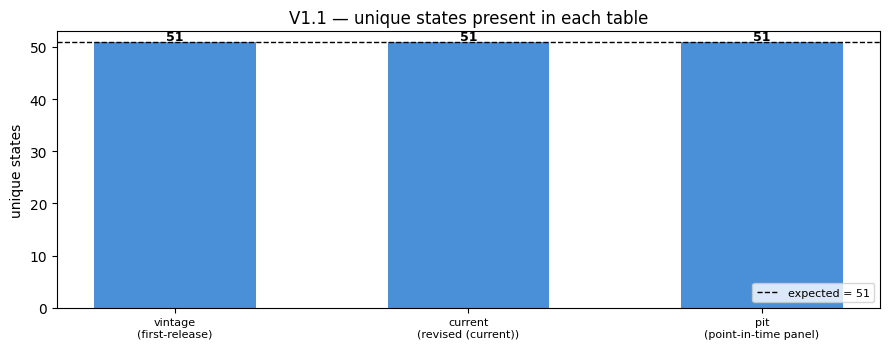

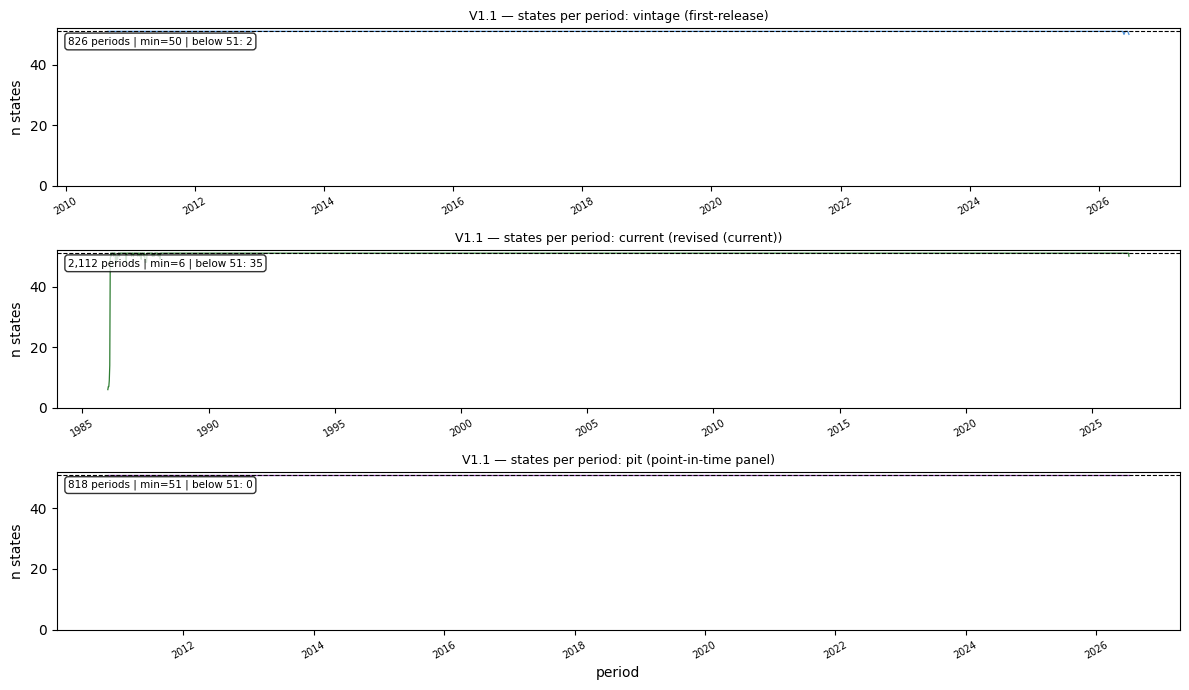

V1.1 — states per period summary (min / max / avg):
  vintage   min=50  max=51  avg= 51.0  below 51: 2  (first-release)
  current   min= 6  max=51  avg= 50.9  below 51: 35  (revised (current))
  pit       min=51  max=51  avg= 51.0  below 51: 0  (point-in-time panel)

V1.1 — periods with < 51 states (all dates):

  vintage (first-release): 2 period(s)
    2026-05-23 00:00:00  (50 states)
    2026-06-20 00:00:00  (50 states)

  current (revised (current)): 35 period(s)
    1986-01-04 00:00:00  (6 states)
    1986-01-11 00:00:00  (7 states)
    1986-01-18 00:00:00  (7 states)
    1986-01-25 00:00:00  (9 states)
    1986-02-01 00:00:00  (14 states)
    1986-02-08 00:00:00  (49 states)
    1986-02-22 00:00:00  (50 states)
    1986-03-29 00:00:00  (50 states)
    1986-04-26 00:00:00  (48 states)
    1986-05-03 00:00:00  (48 states)
    1986-05-10 00:00:00  (50 states)
    1986-05-17 00:00:00  (50 states)
    1986-05-24 00:00:00  (49 states)
    1986-05-31 00:00:00  (50 states)
    1986-06-21

In [23]:
# V1.1 — count unique states per dataset, then plot states reporting each period
N_EXPECTED = 51

_DATASETS = [
    ("vintage", cc_v, "obs_date", "#4a90d9", "first-release"),
    ("current", cc_c, "obs_date", "#2e7d32", "revised (current)"),
    ("pit",     pit, "as_of_date", "#8e44ad", "point-in-time panel"),
]

# (1) static universe: unique states in each table
n_states_tbl = {name: df["state"].nunique() for name, df, _, _, _ in _DATASETS}
print("V1.1 — unique states per table (criterion: 51 everywhere):")
for name, n in n_states_tbl.items():
    flag = "OK" if n == N_EXPECTED else "MISSING"
    print(f"  {name:8s}  {n:2d}  [{flag}]")

_labels = [f"{n}\n({tag})" for n, _, _, _, tag in _DATASETS]
_counts = [n_states_tbl[n] for n, _, _, _, _ in _DATASETS]
_colors = ["#4a90d9" if n == N_EXPECTED else "#d94a4a" for n in _counts]

fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.bar(range(len(_labels)), _counts, color=_colors, width=0.55)
ax.axhline(N_EXPECTED, color="black", ls="--", lw=1, label=f"expected = {N_EXPECTED}")
ax.set_xticks(range(len(_labels)))
ax.set_xticklabels(_labels, fontsize=8)
ax.set_ylabel("unique states")
ax.set_ylim(0, N_EXPECTED + 2)
ax.set_title("V1.1 — unique states present in each table")
for bar, n in zip(bars, _counts):
    ax.text(bar.get_x() + bar.get_width() / 2, n + 0.3, str(n),
            ha="center", fontsize=9, fontweight="bold")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

# (2) states reporting per period over time (panel completeness by period)
per_period_stats = {}
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=False)
for ax, (name, df, date_col, color, tag) in zip(axes, _DATASETS):
    per = df.groupby(date_col)["state"].nunique().sort_index()
    per_period_stats[name] = per
    ax.plot(per.index, per.values, color=color, lw=0.9)
    ax.axhline(N_EXPECTED, color="black", ls="--", lw=0.8)
    ax.set_ylabel("n states")
    ax.set_ylim(0, N_EXPECTED + 1)
    ax.set_title(f"V1.1 — states per period: {name} ({tag})", fontsize=9)
    below = int((per < N_EXPECTED).sum())
    ax.text(
        0.01, 0.95,
        f"{len(per):,} periods | min={per.min()} | below {N_EXPECTED}: {below}",
        transform=ax.transAxes, va="top", fontsize=7.5,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
    )
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
axes[-1].set_xlabel("period")
plt.tight_layout(); plt.show()

print("V1.1 — states per period summary (min / max / avg):")
for name, _, _, _, tag in _DATASETS:
    per = per_period_stats[name]
    below = int((per < N_EXPECTED).sum())
    print(f"  {name:8s}  min={per.min():2d}  max={per.max():2d}  avg={per.mean():5.1f}  below {N_EXPECTED}: {below}  ({tag})")

print(f"\nV1.1 — periods with < {N_EXPECTED} states (all dates):")
for name, _, _, _, tag in _DATASETS:
    per = per_period_stats[name]
    incomplete = per[per < N_EXPECTED]
    print(f"\n  {name} ({tag}): {len(incomplete):,} period(s)")
    if incomplete.empty:
        print("    (none)")
    else:
        for dt, n in incomplete.items():
            print(f"    {dt}  ({int(n)} states)")

## V1.2 — Count and plot (state, claim_type, week) per dataset

V1.2 — (state, claim_type, week) key integrity (criterion: 0 duplicate rows):
  vintage   rows=84,248  unique keys=84,248  dup rows=0  [OK]  key=(state, claim_type, obs_date) (first-release)
  current   rows=214,909  unique keys=214,909  dup rows=0  [OK]  key=(state, claim_type, obs_date) (revised (current))
  pit       rows=41,718  unique keys=41,718  dup rows=0  [OK]  key=(as_of_date, state) (point-in-time panel)


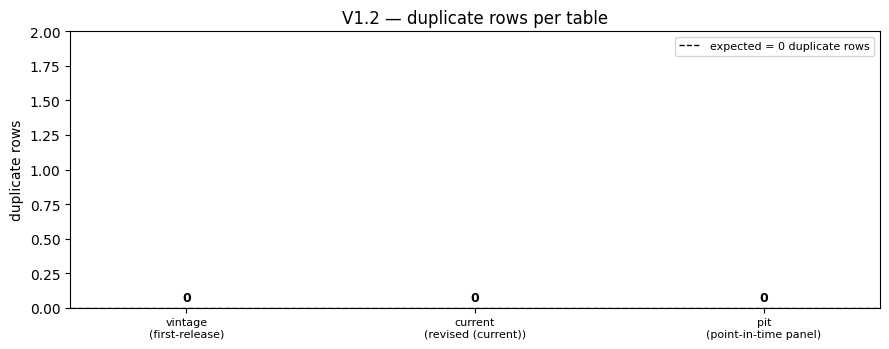

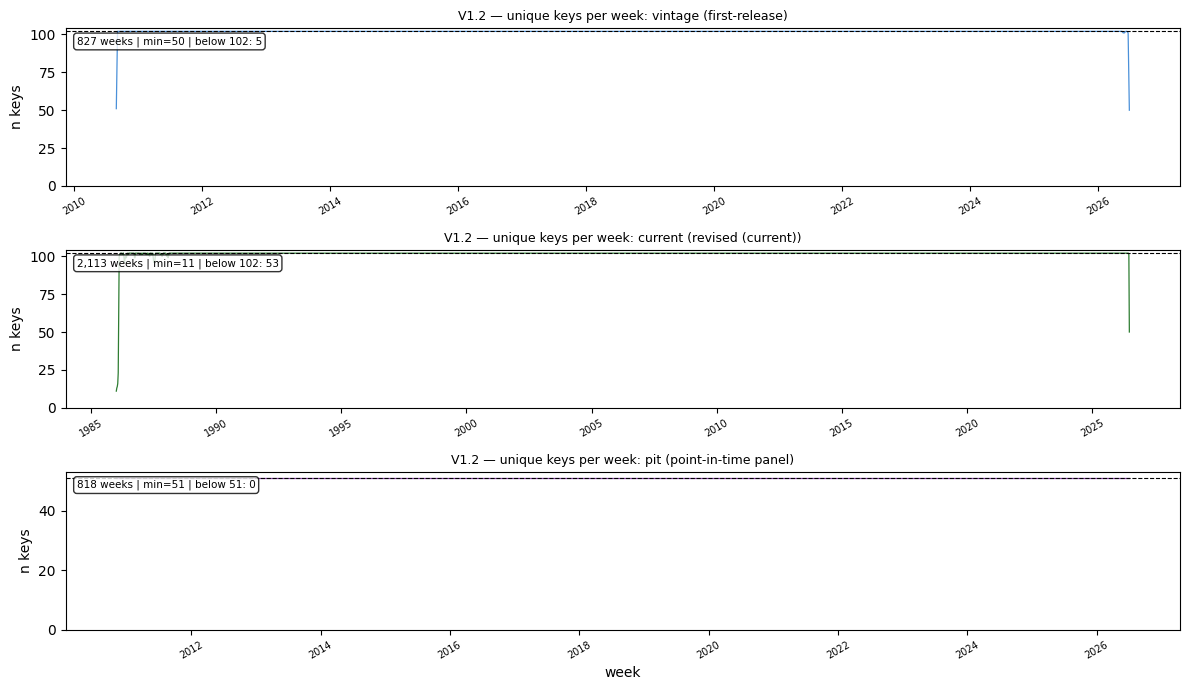

V1.2 — unique keys per week summary (min / max / avg):
  vintage   min= 50  max=102  avg= 101.9  below 102: 5  (first-release)
  current   min= 11  max=102  avg= 101.7  below 102: 53  (revised (current))
  pit       min= 51  max= 51  avg=  51.0  below 51: 0  (point-in-time panel)

V1.2 — weeks with < expected unique keys (all dates):

  vintage (first-release): 5 week(s) below 102
    2010-08-28 00:00:00  (51 keys)
    2026-05-23 00:00:00  (101 keys)
    2026-05-30 00:00:00  (101 keys)
    2026-06-20 00:00:00  (101 keys)
    2026-06-27 00:00:00  (50 keys)

  current (revised (current)): 53 week(s) below 102
    1986-01-04 00:00:00  (11 keys)
    1986-01-11 00:00:00  (13 keys)
    1986-01-18 00:00:00  (14 keys)
    1986-01-25 00:00:00  (16 keys)
    1986-02-01 00:00:00  (23 keys)
    1986-02-08 00:00:00  (63 keys)
    1986-02-15 00:00:00  (100 keys)
    1986-02-22 00:00:00  (101 keys)
    1986-03-01 00:00:00  (101 keys)
    1986-03-29 00:00:00  (101 keys)
    1986-04-05 00:00:00  (101 k

In [24]:
# V1.2 — count and plot (state, claim_type, week) keys per dataset
N_STATES = 51
N_CLAIM_TYPES = df_v["claim_type"].nunique()
EXPECTED_VC = N_STATES * N_CLAIM_TYPES  # 102 (state, claim_type) pairs per week

_DATASETS_V12 = [
    ("vintage", df_v, "obs_date", ["state", "claim_type", "obs_date"], EXPECTED_VC, "#4a90d9", "first-release"),
    ("current", df_c, "obs_date", ["state", "claim_type", "obs_date"], EXPECTED_VC, "#2e7d32", "revised (current)"),
    ("pit",     pit, "as_of_date", ["as_of_date", "state"], N_STATES, "#8e44ad", "point-in-time panel"),
]

# (1) static: row counts, unique keys, duplicate rows
_key_stats = {}
for name, df, _, key_cols, _, _, _ in _DATASETS_V12:
    dup_mask = df.duplicated(key_cols, keep=False)
    _key_stats[name] = {
        "rows": len(df),
        "unique": df.drop_duplicates(key_cols).shape[0],
        "dup_rows": int(dup_mask.sum()),
        "key_cols": key_cols,
    }

print("V1.2 — (state, claim_type, week) key integrity (criterion: 0 duplicate rows):")
for name, _, _, key_cols, expected, _, tag in _DATASETS_V12:
    s = _key_stats[name]
    key_label = "(state, claim_type, obs_date)" if "claim_type" in key_cols else "(as_of_date, state)"
    flag = "OK" if s["dup_rows"] == 0 else "DUP"
    print(
        f"  {name:8s}  rows={s['rows']:,}  unique keys={s['unique']:,}  "
        f"dup rows={s['dup_rows']}  [{flag}]  key={key_label} ({tag})"
    )

_labels = [f"{n}\n({tag})" for n, _, _, _, _, _, tag in _DATASETS_V12]
_dup_counts = [_key_stats[n]["dup_rows"] for n, _, _, _, _, _, _ in _DATASETS_V12]
_colors = ["#2e7d32" if d == 0 else "#d94a4a" for d in _dup_counts]

fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.bar(range(len(_labels)), _dup_counts, color=_colors, width=0.55)
ax.axhline(0, color="black", ls="--", lw=1, label="expected = 0 duplicate rows")
ax.set_xticks(range(len(_labels)))
ax.set_xticklabels(_labels, fontsize=8)
ax.set_ylabel("duplicate rows")
ax.set_ylim(0, max(_dup_counts + [1]) + 1)
ax.set_title("V1.2 — duplicate rows per table")
for bar, d in zip(bars, _dup_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, d + 0.05, str(d),
            ha="center", fontsize=9, fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

# (2) unique keys per week over time
per_week_keys = {}
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=False)
for ax, (name, df, date_col, key_cols, expected, color, tag) in zip(axes, _DATASETS_V12):
    per = df.drop_duplicates(key_cols).groupby(date_col).size().sort_index()
    per_week_keys[name] = per
    ax.plot(per.index, per.values, color=color, lw=0.9)
    ax.axhline(expected, color="black", ls="--", lw=0.8)
    ax.set_ylabel("n keys")
    ax.set_ylim(0, expected + 2)
    ax.set_title(f"V1.2 — unique keys per week: {name} ({tag})", fontsize=9)
    below = int((per < expected).sum())
    ax.text(
        0.01, 0.95,
        f"{len(per):,} weeks | min={per.min()} | below {expected}: {below}",
        transform=ax.transAxes, va="top", fontsize=7.5,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
    )
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
axes[-1].set_xlabel("week")
plt.tight_layout(); plt.show()

print("V1.2 — unique keys per week summary (min / max / avg):")
for name, _, _, _, expected, _, tag in _DATASETS_V12:
    per = per_week_keys[name]
    below = int((per < expected).sum())
    print(
        f"  {name:8s}  min={per.min():3d}  max={per.max():3d}  avg={per.mean():6.1f}  "
        f"below {expected}: {below}  ({tag})"
    )

print(f"\nV1.2 — weeks with < expected unique keys (all dates):")
for name, df, date_col, key_cols, expected, _, tag in _DATASETS_V12:
    per = per_week_keys[name]
    incomplete = per[per < expected]
    print(f"\n  {name} ({tag}): {len(incomplete):,} week(s) below {expected}")
    if incomplete.empty:
        print("    (none)")
    else:
        for dt, n in incomplete.items():
            print(f"    {dt}  ({int(n)} keys)")

print("\nV1.2 — duplicate key instances (all):")
for name, df, _, key_cols, _, _, tag in _DATASETS_V12:
    dup_mask = df.duplicated(key_cols, keep=False)
    print(f"\n  {name} ({tag}): {int(dup_mask.sum())} duplicate row(s)")
    if not dup_mask.any():
        print("    (none)")
    else:
        dup_keys = (
            df.loc[dup_mask, key_cols]
            .value_counts()
            .rename("n_rows")
            .reset_index()
            .sort_values(key_cols)
        )
        print(dup_keys.to_string(index=False))

## V1.3 — Count and plot nulls in the key fields

V1.3 — nulls in key fields (criterion: 0 nulls in vintage + current check fields):

  vintage (first-release): 0 null(s) in check fields  [OK]
    state                   0
    claim_type              0
    obs_date                0
    first_release_date      0
    value_first_release     0

  current (revised (current)): 0 null(s) in check fields  [OK]
    state                   0
    claim_type              0
    obs_date                0
    value_current           0

  pit (point-in-time panel): 0 null(s) in check fields  [OK]
    as_of_date              0
    state                   0


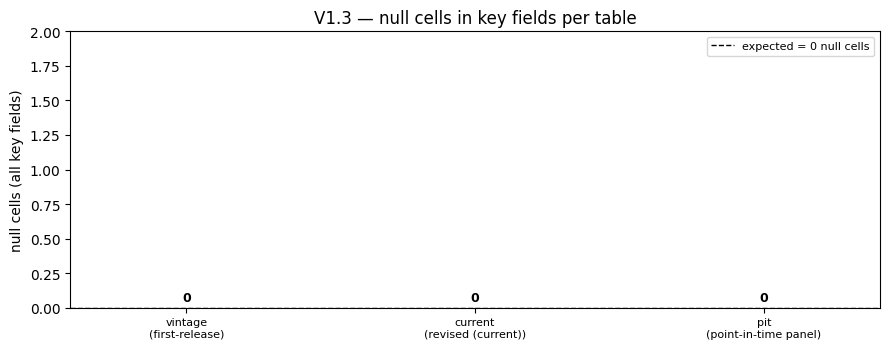

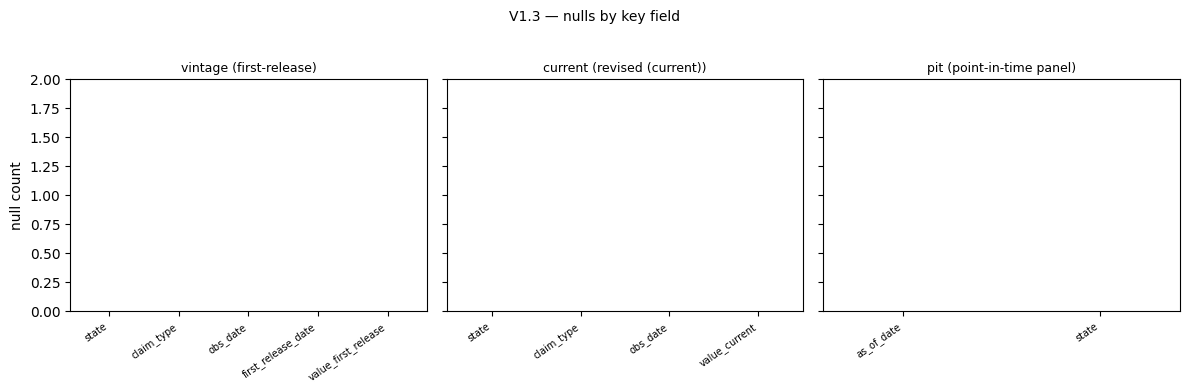

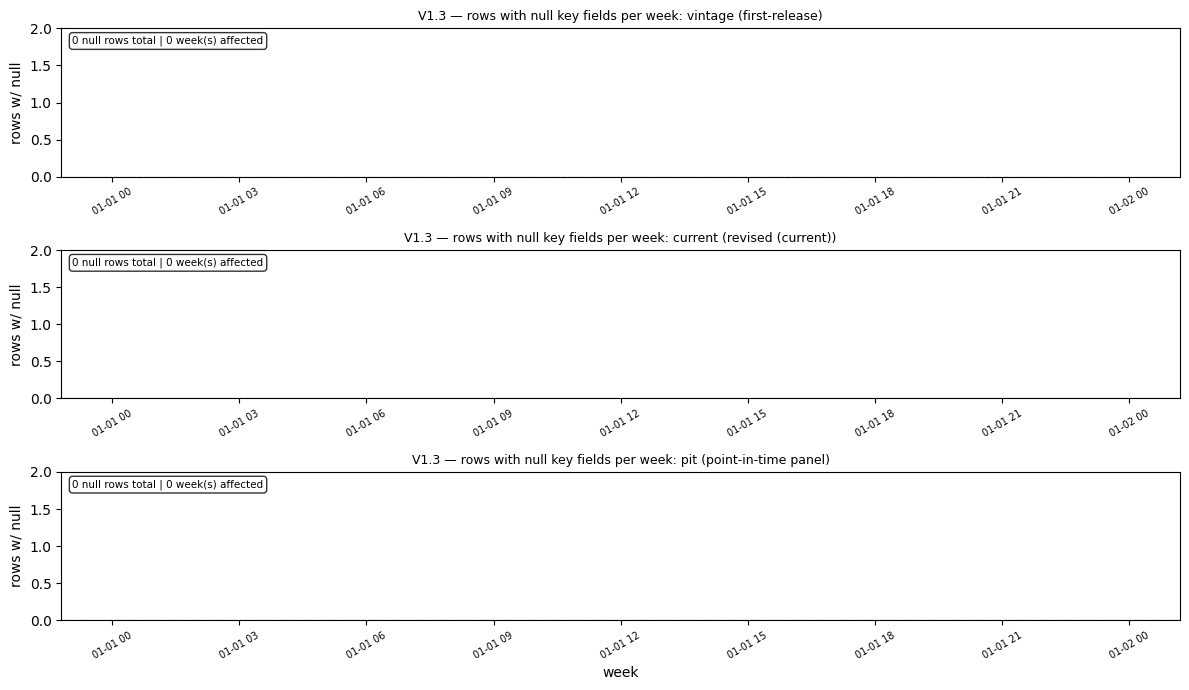

V1.3 — null rows summary:
  vintage   null rows=0  weeks w/ nulls=0  (first-release)
  current   null rows=0  weeks w/ nulls=0  (revised (current))
  pit       null rows=0  weeks w/ nulls=0  (point-in-time panel)

V1.3 — rows with null key fields (all):

  vintage (first-release): 0 row(s)
    (none)

  current (revised (current)): 0 row(s)
    (none)

  pit (point-in-time panel): 0 row(s)
    (none)


In [25]:
# V1.3 — count and plot nulls in key fields per dataset
_KEY_FIELDS_V13 = {
    "vintage": ["state", "claim_type", "obs_date", "first_release_date", "value_first_release"],
    "current": ["state", "claim_type", "obs_date", "value_current"],
    "pit": ["as_of_date", "state"],
}
_CHECK_FIELDS_V13 = {
    "vintage": ["state", "obs_date", "first_release_date", "value_first_release"],
    "current": ["state", "obs_date", "value_current"],
}
_DATE_COL_V13 = {"vintage": "obs_date", "current": "obs_date", "pit": "as_of_date"}
_COLORS_V13 = {"vintage": "#4a90d9", "current": "#2e7d32", "pit": "#8e44ad"}
_TAGS_V13 = {"vintage": "first-release", "current": "revised (current)", "pit": "point-in-time panel"}
_DFS_V13 = {"vintage": df_v, "current": df_c, "pit": pit}

# (1) static: null counts per key field
_null_by_field = {}
_null_rows = {}
for name, fields in _KEY_FIELDS_V13.items():
    df = _DFS_V13[name]
    _null_by_field[name] = df[fields].isna().sum()
    _null_rows[name] = int(df[fields].isna().any(axis=1).sum())

print("V1.3 — nulls in key fields (criterion: 0 nulls in vintage + current check fields):")
for name in _KEY_FIELDS_V13:
    check_fields = _CHECK_FIELDS_V13.get(name, _KEY_FIELDS_V13[name])
    check_nulls = int(_DFS_V13[name][check_fields].isna().sum().sum())
    flag = "OK" if check_nulls == 0 else "NULL"
    print(f"\n  {name} ({_TAGS_V13[name]}): {check_nulls} null(s) in check fields  [{flag}]")
    for field, n in _null_by_field[name].items():
        print(f"    {field:22s}  {int(n):,}")

# bar chart: total null cells per table
_labels = [f"{n}\n({_TAGS_V13[n]})" for n in _KEY_FIELDS_V13]
_totals = [int(_null_by_field[n].sum()) for n in _KEY_FIELDS_V13]
_colors = ["#2e7d32" if t == 0 else "#d94a4a" for t in _totals]

fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.bar(range(len(_labels)), _totals, color=_colors, width=0.55)
ax.axhline(0, color="black", ls="--", lw=1, label="expected = 0 null cells")
ax.set_xticks(range(len(_labels)))
ax.set_xticklabels(_labels, fontsize=8)
ax.set_ylabel("null cells (all key fields)")
ax.set_ylim(0, max(_totals + [1]) + 1)
ax.set_title("V1.3 — null cells in key fields per table")
for bar, t in zip(bars, _totals):
    ax.text(bar.get_x() + bar.get_width() / 2, t + 0.05, str(t),
            ha="center", fontsize=9, fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

# grouped bar chart: nulls by field within each dataset
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, name in zip(axes, _KEY_FIELDS_V13):
    counts = _null_by_field[name]
    x = range(len(counts))
    cols = ["#2e7d32" if v == 0 else "#d94a4a" for v in counts.values]
    ax.bar(x, counts.values, color=cols, width=0.65)
    ax.set_xticks(x)
    ax.set_xticklabels(counts.index, rotation=35, ha="right", fontsize=7)
    ax.set_title(f"{name} ({_TAGS_V13[name]})", fontsize=9)
    ax.set_ylim(0, max(_totals + [1]) + 1)
    for i, v in enumerate(counts.values):
        if v:
            ax.text(i, v + 0.05, str(int(v)), ha="center", fontsize=8, fontweight="bold")
axes[0].set_ylabel("null count")
fig.suptitle("V1.3 — nulls by key field", fontsize=10, y=1.02)
plt.tight_layout(); plt.show()

# (2) rows with any null key field per week over time
per_week_null_rows = {}
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=False)
for ax, name in zip(axes, _KEY_FIELDS_V13):
    df = _DFS_V13[name]
    fields = _KEY_FIELDS_V13[name]
    date_col = _DATE_COL_V13[name]
    null_mask = df[fields].isna().any(axis=1)
    per = df.loc[null_mask].groupby(date_col).size().sort_index()
    per_week_null_rows[name] = per
    ax.plot(per.index, per.values, color=_COLORS_V13[name], lw=0.9)
    ax.axhline(0, color="black", ls="--", lw=0.8)
    ax.set_ylabel("rows w/ null")
    ax.set_ylim(0, max(per.max() if len(per) else 0, 1) + 1)
    ax.set_title(f"V1.3 — rows with null key fields per week: {name} ({_TAGS_V13[name]})", fontsize=9)
    ax.text(
        0.01, 0.95,
        f"{_null_rows[name]:,} null rows total | {len(per):,} week(s) affected",
        transform=ax.transAxes, va="top", fontsize=7.5,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
    )
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
axes[-1].set_xlabel("week")
plt.tight_layout(); plt.show()

print("V1.3 — null rows summary:")
for name in _KEY_FIELDS_V13:
    print(
        f"  {name:8s}  null rows={_null_rows[name]:,}  "
        f"weeks w/ nulls={len(per_week_null_rows[name]):,}  ({_TAGS_V13[name]})"
    )

print("\nV1.3 — rows with null key fields (all):")
for name in _KEY_FIELDS_V13:
    df = _DFS_V13[name]
    fields = _KEY_FIELDS_V13[name]
    bad = df[df[fields].isna().any(axis=1)]
    print(f"\n  {name} ({_TAGS_V13[name]}): {len(bad):,} row(s)")
    if bad.empty:
        print("    (none)")
    else:
        show_cols = fields + [c for c in df.columns if c not in fields][:3]
        print(bad[show_cols].head(50).to_string(index=False))
        if len(bad) > 50:
            print(f"    ... {len(bad) - 50:,} more row(s)")

## V1.4 — Values parseable, finite and positive


V1.4 — values parseable, finite and positive (criterion: 0 bad; startup-era zeros → WARN):
  vintage   bad rows=0  [OK]  (first-release)
  current   bad rows=15  [BAD]  (revised (current))
  current zeros (<=0): 15  latest=1986-07-19  post-1990=0


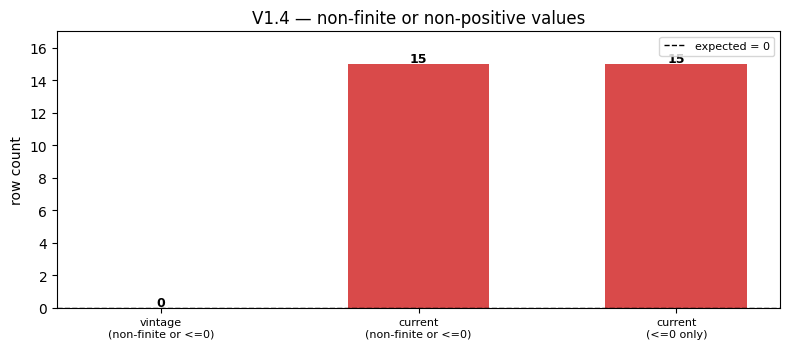

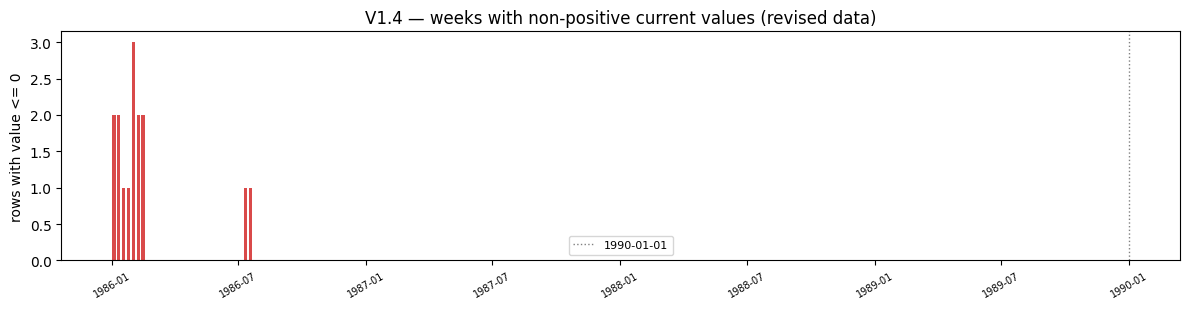


V1.4 — all non-finite or non-positive rows (vintage):
  (none)

V1.4 — all non-positive rows (current, value <= 0):
     state claim_type   obs_date  value_current
  Colorado    cclaims 1986-01-04            0.0
  Colorado    cclaims 1986-01-11            0.0
  Colorado    cclaims 1986-01-25            0.0
  Colorado    cclaims 1986-02-01            0.0
  Colorado    iclaims 1986-01-04            0.0
  Colorado    iclaims 1986-01-11            0.0
  Colorado    iclaims 1986-01-18            0.0
  Colorado    iclaims 1986-02-01            0.0
  Colorado    iclaims 1986-02-08            0.0
      Iowa    cclaims 1986-02-01            0.0
      Iowa    iclaims 1986-02-08            0.0
New Jersey    iclaims 1986-07-12            0.0
New Jersey    iclaims 1986-07-19            0.0
New Mexico    iclaims 1986-02-15            0.0
  Virginia    iclaims 1986-02-15            0.0


In [26]:
# V1.4 — values parseable, finite and positive (incl. FRED int→float drift)
_VAL_COLS_V14 = {
    "vintage": ("value_first_release", df_v, "obs_date", "#4a90d9", "first-release"),
    "current": ("value_current", df_c, "obs_date", "#2e7d32", "revised (current)"),
}

def _bad_mask(series):
    return ~series.apply(lambda x: isinstance(x, (int, float, np.integer, np.floating)) and np.isfinite(x) and x > 0)

_bad_rows = {}
for name, (col, df, date_col, color, tag) in _VAL_COLS_V14.items():
    mask = _bad_mask(df[col])
    _bad_rows[name] = df.loc[mask, ["state", "claim_type", date_col, col]].copy()
    _bad_rows[name].rename(columns={date_col: "obs_date", col: "value"}, inplace=True)

nonpos = df_c[df_c["value_current"] <= 0].copy()
nonpos_recent = nonpos[nonpos["obs_date"] >= "1990-01-01"]
bad_v = len(_bad_rows["vintage"])
bad_c = len(_bad_rows["current"])
n_nonpos = len(nonpos)

print("V1.4 — values parseable, finite and positive (criterion: 0 bad; startup-era zeros → WARN):")
for name, (_, _, _, _, tag) in _VAL_COLS_V14.items():
    n = len(_bad_rows[name])
    flag = "OK" if n == 0 else "BAD"
    print(f"  {name:8s}  bad rows={n:,}  [{flag}]  ({tag})")
print(f"  current zeros (<=0): {n_nonpos:,}  latest={nonpos['obs_date'].max().date() if n_nonpos else 'n/a'}  post-1990={len(nonpos_recent)}")

# bar chart: bad / non-positive counts
_labels = ["vintage\n(non-finite or <=0)", "current\n(non-finite or <=0)", "current\n(<=0 only)"]
_counts = [bad_v, bad_c, n_nonpos]
_colors = ["#2e7d32" if c == 0 else "#d94a4a" for c in _counts]

fig, ax = plt.subplots(figsize=(8, 3.6))
bars = ax.bar(range(len(_labels)), _counts, color=_colors, width=0.55)
ax.axhline(0, color="black", ls="--", lw=1, label="expected = 0")
ax.set_xticks(range(len(_labels)))
ax.set_xticklabels(_labels, fontsize=8)
ax.set_ylabel("row count")
ax.set_ylim(0, max(_counts + [1]) + 2)
ax.set_title("V1.4 — non-finite or non-positive values")
for bar, c in zip(bars, _counts):
    ax.text(bar.get_x() + bar.get_width() / 2, c + 0.1, str(c),
            ha="center", fontsize=9, fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

# time series: weeks with any <=0 current value
_nonpos_by_week = nonpos.groupby("obs_date").size().sort_index()
fig, ax = plt.subplots(figsize=(12, 3.2))
if len(_nonpos_by_week):
    ax.bar(_nonpos_by_week.index, _nonpos_by_week.values, color="#d94a4a", width=5)
ax.axvline(pd.Timestamp("1990-01-01"), color="gray", ls=":", lw=1, label="1990-01-01")
ax.set_ylabel("rows with value <= 0")
ax.set_title("V1.4 — weeks with non-positive current values (revised data)")
ax.legend(fontsize=8)
ax.tick_params(axis="x", labelrotation=30, labelsize=7)
plt.tight_layout(); plt.show()

print("\nV1.4 — all non-finite or non-positive rows (vintage):")
if bad_v == 0:
    print("  (none)")
else:
    print(_bad_rows["vintage"].sort_values(["state", "claim_type", "obs_date"]).to_string(index=False))

print("\nV1.4 — all non-positive rows (current, value <= 0):")
if n_nonpos == 0:
    print("  (none)")
else:
    print(
        nonpos[["state", "claim_type", "obs_date", "value_current"]]
        .sort_values(["state", "claim_type", "obs_date"])
        .to_string(index=False)
    )


## V1.4b — Zero position: leading (ramp-in) vs interior (dropout)


V1.4b — zero position (criterion: interior == 0 ideally; pre-1990 interior → WARN):
  leading (ramp-in):  9
  interior (dropout): 6  (post-1990: 0)

V1.4b — zeros by state / claim_type:
     state claim_type  interior  leading  total_zeros
  Colorado    cclaims         2        2            4
  Colorado    iclaims         2        3            5
      Iowa    cclaims         0        1            1
      Iowa    iclaims         0        1            1
New Jersey    iclaims         2        0            2
New Mexico    iclaims         0        1            1
  Virginia    iclaims         0        1            1


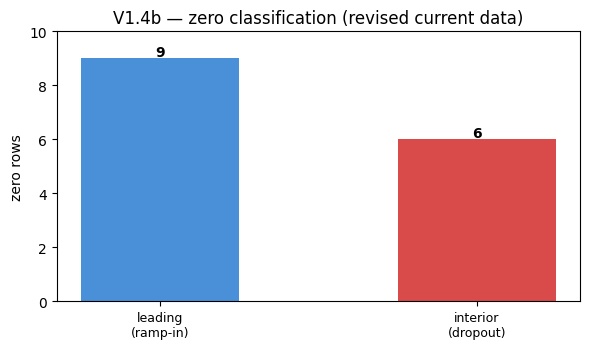


V1.4b — all zero rows with position:
     state claim_type   obs_date position
  Colorado    cclaims 1986-01-25 interior
  Colorado    cclaims 1986-02-01 interior
  Colorado    iclaims 1986-02-01 interior
  Colorado    iclaims 1986-02-08 interior
New Jersey    iclaims 1986-07-12 interior
New Jersey    iclaims 1986-07-19 interior
  Colorado    cclaims 1986-01-04  leading
  Colorado    cclaims 1986-01-11  leading
  Colorado    iclaims 1986-01-04  leading
  Colorado    iclaims 1986-01-11  leading
  Colorado    iclaims 1986-01-18  leading
      Iowa    cclaims 1986-02-01  leading
      Iowa    iclaims 1986-02-08  leading
New Mexico    iclaims 1986-02-15  leading
  Virginia    iclaims 1986-02-15  leading


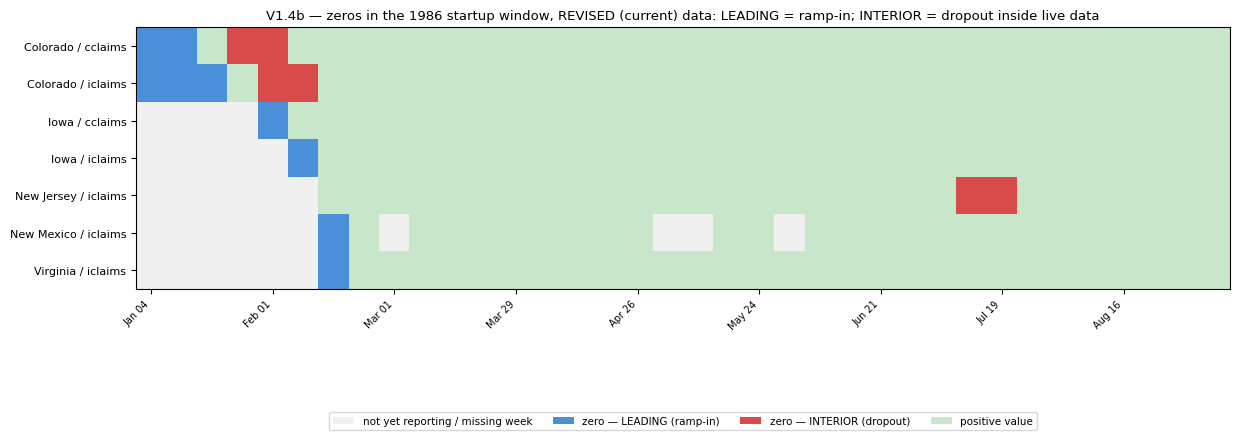

In [27]:
# V1.4b — zero position: leading (ramp-in) vs interior (mid-sample dropout)
zero_class = []
for (state, ct), g in df_c.groupby(["state", "claim_type"]):
    z = g[g["value_current"] <= 0]
    if not len(z):
        continue
    first_nonzero = g.loc[g["value_current"] > 0, "obs_date"].min()
    for _, r in z.iterrows():
        zero_class.append({
            "state": state, "claim_type": ct, "obs_date": r["obs_date"],
            "position": "leading" if r["obs_date"] < first_nonzero else "interior",
        })
zero_class = pd.DataFrame(zero_class)

n_lead = int((zero_class["position"] == "leading").sum()) if len(zero_class) else 0
n_int = int((zero_class["position"] == "interior").sum()) if len(zero_class) else 0
int_recent = (
    zero_class[(zero_class["position"] == "interior") & (zero_class["obs_date"] >= "1990-01-01")]
    if len(zero_class) else zero_class
)

print("V1.4b — zero position (criterion: interior == 0 ideally; pre-1990 interior → WARN):")
print(f"  leading (ramp-in):  {n_lead}")
print(f"  interior (dropout): {n_int}  (post-1990: {len(int_recent)})")

# summary table by (state, claim_type)
if len(zero_class):
    _zc_summary = (
        zero_class.groupby(["state", "claim_type", "position"]).size()
        .unstack(fill_value=0)
        .reset_index()
    )
    for col in ["leading", "interior"]:
        if col not in _zc_summary.columns:
            _zc_summary[col] = 0
    _zc_summary["total_zeros"] = _zc_summary["leading"] + _zc_summary["interior"]
    print("\nV1.4b — zeros by state / claim_type:")
    print(_zc_summary.sort_values(["state", "claim_type"]).to_string(index=False))
else:
    print("\n  (no zeros)")

# bar chart: leading vs interior
_pos_labels = ["leading\n(ramp-in)", "interior\n(dropout)"]
_pos_counts = [n_lead, n_int]
_pos_colors = ["#4a90d9", "#d94a4a" if n_int else "#2e7d32"]

fig, ax = plt.subplots(figsize=(6, 3.6))
bars = ax.bar(range(2), _pos_counts, color=_pos_colors, width=0.5)
ax.set_xticks(range(2))
ax.set_xticklabels(_pos_labels, fontsize=9)
ax.set_ylabel("zero rows")
ax.set_ylim(0, max(_pos_counts + [1]) + 1)
ax.set_title("V1.4b — zero classification (revised current data)")
for bar, c in zip(bars, _pos_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, c + 0.1, str(c),
            ha="center", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

print("\nV1.4b — all zero rows with position:")
if len(zero_class):
    print(zero_class.sort_values(["position", "state", "claim_type", "obs_date"]).to_string(index=False))
else:
    print("  (none)")

# heatmap: 1986 startup window
if len(zero_class):
    from matplotlib.colors import ListedColormap, BoundaryNorm
    from matplotlib.patches import Patch

    pairs = sorted({(r.state, r.claim_type) for r in zero_class.itertuples()})
    weeks = pd.date_range("1986-01-04", "1986-09-06", freq="W-SAT")
    M = np.zeros((len(pairs), len(weeks)))
    for r_i, (st, ct) in enumerate(pairs):
        g = df_c[(df_c["state"] == st) & (df_c["claim_type"] == ct)].set_index("obs_date")["value_current"]
        first_nonzero = g[g > 0].index.min()
        for c_i, w in enumerate(weeks):
            if w in g.index:
                v = g.loc[w]
                if v > 0:
                    M[r_i, c_i] = 3
                else:
                    M[r_i, c_i] = 1 if w < first_nonzero else 2
    cmap = ListedColormap(["#f0f0f0", "#4a90d9", "#d94a4a", "#c8e6c9"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)
    fig, ax = plt.subplots(figsize=(12.5, 0.5 * len(pairs) + 1.6))
    ax.imshow(M, aspect="auto", cmap=cmap, norm=norm)
    ax.set_yticks(range(len(pairs)))
    ax.set_yticklabels([f"{s} / {c}" for s, c in pairs], fontsize=8)
    ax.set_xticks(range(0, len(weeks), 4))
    ax.set_xticklabels([w.strftime("%b %d") for w in weeks[::4]], rotation=45, ha="right", fontsize=7)
    ax.set_title(
        "V1.4b — zeros in the 1986 startup window, REVISED (current) data: "
        "LEADING = ramp-in; INTERIOR = dropout inside live data",
        fontsize=9.5,
    )
    ax.legend(
        handles=[
            Patch(fc="#f0f0f0", label="not yet reporting / missing week"),
            Patch(fc="#4a90d9", label="zero — LEADING (ramp-in)"),
            Patch(fc="#d94a4a", label="zero — INTERIOR (dropout)"),
            Patch(fc="#c8e6c9", label="positive value"),
        ],
        fontsize=7.5, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.45),
    )
    plt.tight_layout(); plt.show()


## V1.5 — Row counts per state (fetch truncation check)


V1.5 — row counts per state, continued-claims current history
  (criterion: max - min <= 15 weeks; spread=12)
  min=2100  max=2112  median=2107  n_states=51

V1.5 — rows per state (sorted ascending):
               state  n_rows  vs_median
          New Mexico    2100       -7.0
              Nevada    2103       -4.0
          California    2103       -4.0
             Vermont    2103       -4.0
            Oklahoma    2103       -4.0
              Hawaii    2103       -4.0
           Louisiana    2104       -3.0
            Missouri    2105       -2.0
          New Jersey    2106       -1.0
      North Carolina    2106       -1.0
                Ohio    2106       -1.0
        Rhode Island    2106       -1.0
           Tennessee    2106       -1.0
            Delaware    2106       -1.0
              Alaska    2106       -1.0
           Wisconsin    2106       -1.0
            Nebraska    2107        0.0
        Pennsylvania    2107        0.0
              Oregon    2107        0.0


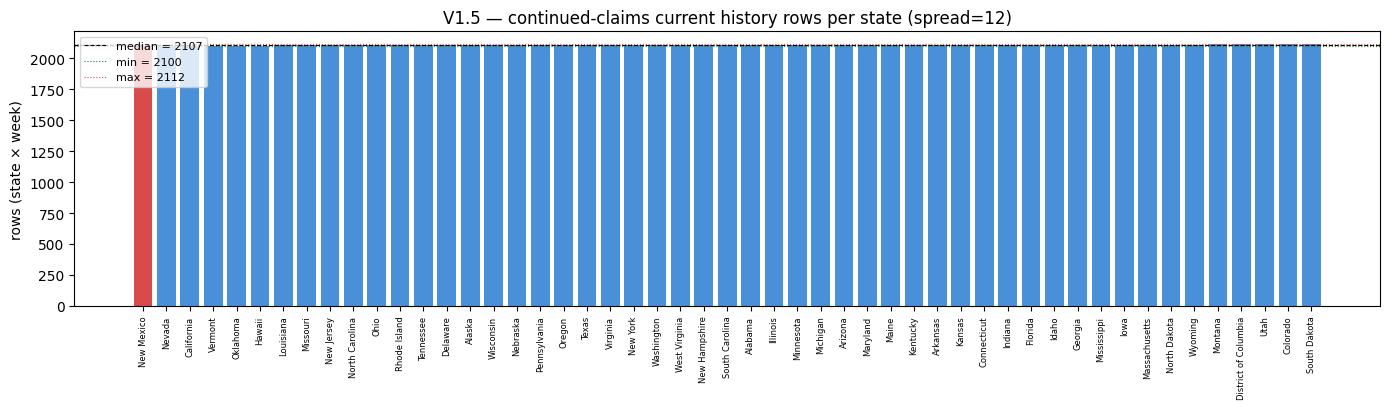

In [28]:
# V1.5 — row counts per state (fetch truncation check)
rc = cc_c.groupby("state").size().sort_values()
rc_min, rc_max = int(rc.min()), int(rc.max())
rc_spread = rc_max - rc_min
rc_median = float(rc.median())

print("V1.5 — row counts per state, continued-claims current history")
print(f"  (criterion: max - min <= 15 weeks; spread={rc_spread})")
print(f"  min={rc_min}  max={rc_max}  median={rc_median:.0f}  n_states={len(rc)}")

# table: all states sorted by row count
_rc_tbl = rc.reset_index(name="n_rows")
_rc_tbl["vs_median"] = _rc_tbl["n_rows"] - rc_median
print("\nV1.5 — rows per state (sorted ascending):")
print(_rc_tbl.to_string(index=False))

# highlight outliers (>5 weeks from median)
_outliers = _rc_tbl[_rc_tbl["vs_median"].abs() > 5]
print(f"\nV1.5 — states >5 weeks from median ({len(_outliers)}):")
if _outliers.empty:
    print("  (none)")
else:
    print(_outliers.to_string(index=False))

# bar chart
_states = rc.index.tolist()
_counts = rc.values
_colors = ["#d94a4a" if (v - rc_median) < -5 or (v - rc_median) > 5 else "#4a90d9" for v in _counts]

fig, ax = plt.subplots(figsize=(14, 4.2))
ax.bar(range(len(_states)), _counts, color=_colors, width=0.8)
ax.axhline(rc_median, color="black", ls="--", lw=0.8, label=f"median = {rc_median:.0f}")
ax.axhline(rc_min, color="#2e7d32", ls=":", lw=0.8, label=f"min = {rc_min}")
ax.axhline(rc_max, color="#d94a4a", ls=":", lw=0.8, label=f"max = {rc_max}")
ax.set_xticks(range(len(_states)))
ax.set_xticklabels(_states, rotation=90, fontsize=6)
ax.set_ylabel("rows (state × week)")
ax.set_title(f"V1.5 — continued-claims current history rows per state (spread={rc_spread})")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()


## V2 — Calendar & frequency — *observation time: the week being measured*

This module validates the **observation clock**: `obs_date` stamps the reference week (always ending **Saturday**, DOL convention). It says *what* the number measures — not when anyone knew it. The information clock (when the number became known) is V3's subject.

| Check | Question it answers |
|---|---|
| V2.1 | Do all observation dates follow the DOL Saturday week-ending convention? |
| V2.2a | Are there missing weeks in the old (pre-1990) history? |
| V2.2b | Are there missing weeks in modern data — live issues to monitor? |
| V2.3 | Do all states cover the same window (balanced panel)? |

In [22]:
### V1 in depth: the shape of the data

Before trusting the *content*, map the *shape*: where observations are missing, how many states report each period, whether any (state, period) key is duplicated, and — for any zero values — whether they are ever revised to non-zero. Covers all three tables used above: **first-release** (vintage), **revised (current)**, and the **point-in-time panel** (PIT). Plot titles state which table each figure uses.


SyntaxError: invalid character '—' (U+2014) (2899030743.py, line 3)

# ── V1 shape audit: missing-value map, coverage over time, duplicate keys ─────
# Three tables: vintage (first-release), current (revised), PIT (point-in-time panel).
_SHAPE_SETS = [
    ("vintage", cc_v, "obs_date", "value_first_release", "W-SAT",
     ["state", "obs_date"], "#4a90d9", "first-release"),
    ("current", cc_c, "obs_date", "value_current", "W-SAT",
     ["state", "obs_date"], "#2e7d32", "revised (current)"),
    ("pit", pit, "as_of_date", "cclaims_t0", "W-FRI",
     ["as_of_date", "state"], "#8e44ad", "point-in-time panel"),
]
_states_sorted = sorted(cc_c["state"].unique())
_n_states = len(_states_sorted)

_shape_wide = {}
_shape_missing = {}
_shape_coverage = {}
_shape_cal = {}

for name, df, date_col, val_col, freq, key_cols, color, tag in _SHAPE_SETS:
    wide = (df.pivot(index=date_col, columns="state", values=val_col)
            .reindex(columns=_states_sorted).sort_index())
    cal = pd.date_range(wide.index.min(), wide.index.max(), freq=freq)
    wide = wide.reindex(cal)
    _shape_wide[name] = wide
    _shape_missing[name] = wide.isna()
    _shape_coverage[name] = wide.notna().sum(axis=1).rename("n_states_reporting")
    _shape_cal[name] = cal

# (1) heatmaps of MISSING observations — one row per table
fig, axes = plt.subplots(3, 1, figsize=(11, 14))
for ax, (name, *rest) in zip(axes, _SHAPE_SETS):
  tag = rest[-1]
  missing = _shape_missing[name]
  cal = _shape_cal[name]
  n_miss = int(missing.values.sum())
  ax.imshow(missing.values, aspect="auto", cmap="Greys", interpolation="nearest", vmin=0, vmax=1)
  ax.set_xticks(range(len(_states_sorted)))
  ax.set_xticklabels(_states_sorted, rotation=90, fontsize=5)
  _yt = np.linspace(0, len(cal) - 1, min(12, len(cal))).astype(int)
  ax.set_yticks(_yt)
  ax.set_yticklabels([cal[i].strftime("%Y-%m") for i in _yt], fontsize=7)
  ax.set_xlabel("state")
  ax.set_ylabel("period")
  ax.set_title(f"V1 — missing observations by state, {tag}  |  black = missing ({n_miss:,} cells)")
plt.tight_layout(); plt.show()

# (2) states reporting per period over time
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=False)
for ax, (name, *rest) in zip(axes, _SHAPE_SETS):
    color, tag = rest[-2], rest[-1]
    cov = _shape_coverage[name]
    ax.plot(cov.index, cov.values, color=color, lw=0.9)
    ax.axhline(_n_states, color="black", ls="--", lw=0.8)
    below = int((cov < _n_states).sum())
    ax.set_ylabel("n states")
    ax.set_ylim(0, _n_states + 1)
    ax.set_title(f"V1 — states per period: {name} ({tag})", fontsize=9)
    ax.text(
        0.01, 0.95,
        f"{len(cov):,} periods | min={cov.min()} | below {_n_states}: {below}",
        transform=ax.transAxes, va="top", fontsize=7.5,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
    )
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
axes[-1].set_xlabel("period")
plt.tight_layout(); plt.show()

print("V1 — values reported per period (distribution of state counts):\n")
for name, df, date_col, val_col, freq, key_cols, color, tag in _SHAPE_SETS:
    cov = _shape_coverage[name]
    cal = _shape_cal[name]
    print(f"  {name} ({tag}):")
    print(cov.value_counts().sort_index().rename("n_periods").to_frame().T.to_string())
    incomplete = cov[cov < _n_states]
    print(f"    incomplete periods (< {_n_states} states): {len(incomplete)} of {len(cal)}")
    if len(incomplete):
        for dt, n in incomplete.head(20).items():
            print(f"      {dt}  ({int(n)} states)")
        if len(incomplete) > 20:
            print(f"      ... +{len(incomplete) - 20} more")
    print()

# (3) duplicate keys per table
print("V1 — duplicate (state, period) keys:")
for name, df, date_col, val_col, freq, key_cols, color, tag in _SHAPE_SETS:
    dupmask = df.duplicated(key_cols, keep=False)
    n_dup = int(dupmask.sum())
    print(f"\n  {name} ({tag}): {n_dup} duplicate row(s)  key={tuple(key_cols)}")
    if n_dup:
        print(df.loc[dupmask, key_cols].value_counts().rename("count").reset_index().to_string(index=False))
    else:
        cnt = df.groupby("state")[date_col].agg(n_obs="size", n_unique_periods="nunique")
        print(f"    no duplicates — per-state period counts: min={cnt['n_obs'].min()} max={cnt['n_obs'].max()} median={cnt['n_obs'].median():.0f}")


OBSERVATION clock:  week ends SATURDAY 2026-05-09   <- the obs_date V2.1 checks
INFORMATION clock:  national advance print published THURSDAY 2026-05-21 = obs + 12d   <- the vintage date V3.2 checks
first state captures in ALFRED for the same week:
   Alabama         2026-05-22 (Friday) = obs + 13d
   Alaska          2026-05-22 (Friday) = obs + 13d
   Arizona         2026-05-22 (Friday) = obs + 13d

Same value, two clocks: obs_date stamps the REFERENCE WEEK (Saturday, DOL convention);
vintage dates stamp PUBLICATION (mid-week reports). No contradiction — and all joins in
a forecasting/backtesting pipeline must use the information clock.


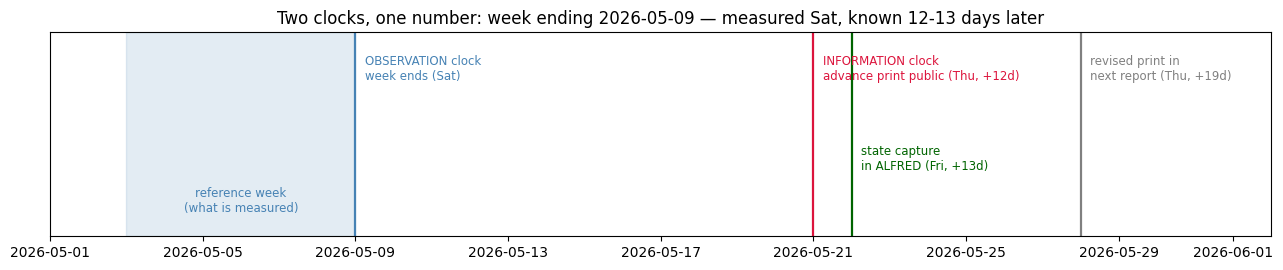

In [6]:
# V3.0 — worked example: the two clocks on one observation week (answers "V2.1 vs V3.2")
# pick a typical week: national on schedule (12d) AND states captured at the modal post-2020 lag (13d)
state_min_lag = cc_v.groupby("obs_date")["pub_lag_days"].min()
typical_weeks = nat_v[nat_v["pub_lag_days"] == 12].merge(
    state_min_lag[state_min_lag == 13].rename("min_lag"), on="obs_date")
ex_obs = typical_weeks["obs_date"].iloc[-3]
ex_nat = nat_v[nat_v["obs_date"] == ex_obs].iloc[0]
ex_states = (cc_v[cc_v["obs_date"] == ex_obs].nsmallest(3, "first_release_date")
             [["state", "first_release_date", "pub_lag_days"]])

print(f"OBSERVATION clock:  week ends SATURDAY {ex_obs.date()}   <- the obs_date V2.1 checks")
print(f"INFORMATION clock:  national advance print published THURSDAY "
      f"{ex_nat['first_release_date'].date()} = obs + {ex_nat['pub_lag_days']:.0f}d   <- the vintage date V3.2 checks")
print("first state captures in ALFRED for the same week:")
for _, r in ex_states.iterrows():
    print(f"   {r['state']:<15s} {r['first_release_date'].date()} "
          f"({r['first_release_date'].day_name()}) = obs + {r['pub_lag_days']:.0f}d")
print()
print("Same value, two clocks: obs_date stamps the REFERENCE WEEK (Saturday, DOL convention);")
print("vintage dates stamp PUBLICATION (mid-week reports). No contradiction — and all joins in")
print("a forecasting/backtesting pipeline must use the information clock.")

# ── visual: the two clocks on a timeline ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 2.8))
week_start = ex_obs - pd.Timedelta(days=6)
ax.axvspan(week_start, ex_obs, alpha=0.15, color="steelblue")
ax.text(week_start + pd.Timedelta(days=3), 0.12, "reference week\n(what is measured)",
        ha="center", fontsize=8.5, color="steelblue")
events = [
    (ex_obs, "OBSERVATION clock\nweek ends (Sat)", "steelblue", 0.82),
    (ex_nat["first_release_date"], "INFORMATION clock\nadvance print public (Thu, +12d)", "crimson", 0.82),
    (ex_states["first_release_date"].iloc[0], "state capture\nin ALFRED (Fri, +13d)", "darkgreen", 0.38),
    (ex_obs + pd.Timedelta(days=19), "revised print in\nnext report (Thu, +19d)", "gray", 0.82),
]
for x, lbl, colr, y in events:
    ax.axvline(x, color=colr, lw=1.6)
    ax.text(x + pd.Timedelta(days=0.25), y, lbl, fontsize=8.5, color=colr, va="center")
ax.set_ylim(0, 1); ax.set_yticks([])
ax.set_xlim(week_start - pd.Timedelta(days=2), ex_obs + pd.Timedelta(days=24))
ax.set_title(f"Two clocks, one number: week ending {ex_obs.date()} — measured Sat, known 12-13 days later")
plt.tight_layout(); plt.show()

In [7]:
# V3.1 vintage boundary — everything before this date is NOT point-in-time
vint_start = df_v["first_release_date"].min()
add_check("V3", "V3.1", "ALFRED vintage boundary identified",
          "WARN",  # structural property, not a defect — WARN keeps it visible in the report
          metric=f"first vintage {vint_start.date()}", threshold="documented",
          note="pre-boundary history (1986->2010-09) exists only as current values: "
               "usable for seasonality/climatology, NOT for backtesting")

# V3.2 national release calendar: Thursday, or Wednesday when holiday-shifted
nat_wd = nat_vdates.dt.dayofweek.value_counts().sort_index()
thu_share = nat_wd.get(3, 0) / len(nat_vdates)
wed_share = nat_wd.get(2, 0) / len(nat_vdates)
add_check("V3", "V3.2", "National CCNSA vintages land mid-week (Thu, or holiday-Wed)",
          "PASS" if thu_share + wed_share >= 0.99 else "FAIL",
          metric=f"Thu {thu_share:.1%}, Wed {wed_share:.1%} of {len(nat_vdates)} vintages",
          threshold="Thu+Wed >= 99%",
          note="Wednesday releases are the holiday-shifted reports (Thanksgiving, Jul 4, ...)")

# V3.3 national first-release lag: advance CC print = week-ending Saturday + 12 days
nat_lag_med = nat_v["pub_lag_days"].median()
add_check("V3", "V3.3", "National CC first release = advance print (Sat + 12d = Thursday)",
          "PASS" if nat_lag_med == 12 else "WARN",
          metric=f"median lag {nat_lag_med:.0f}d (min {nat_v['pub_lag_days'].min()}, max {nat_v['pub_lag_days'].max()})",
          threshold="median == 12d",
          note="CC reference week trails the report by 12 days (one week behind initial claims)")

# V3.4 state capture weekday profile vs the national benchmark
wd_names = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
st_wd = cc_v["first_release_date"].dt.dayofweek.value_counts(normalize=True).sort_index()
thu_fri_wed = st_wd.get(3, 0) + st_wd.get(4, 0) + st_wd.get(2, 0)
add_check("V3", "V3.4", "State captures cluster on/next-day-after release days",
          "PASS" if thu_fri_wed >= 0.90 else "WARN",
          metric=", ".join(f"{wd_names[k]} {v:.1%}" for k, v in st_wd.items()),
          threshold="Thu+Fri+Wed >= 90%",
          note="Mon captures are FRED ingestion delays, not release timing — see V3.5/V3.6")

[WARN] V3.1   ALFRED vintage boundary identified  |  first vintage 2010-09-16  (criterion: documented)
       note: pre-boundary history (1986->2010-09) exists only as current values: usable for seasonality/climatology, NOT for backtesting
[PASS] V3.2   National CCNSA vintages land mid-week (Thu, or holiday-Wed)  |  Thu 96.7%, Wed 3.3% of 867 vintages  (criterion: Thu+Wed >= 99%)
       note: Wednesday releases are the holiday-shifted reports (Thanksgiving, Jul 4, ...)
[PASS] V3.3   National CC first release = advance print (Sat + 12d = Thursday)  |  median lag 12d (min 11, max 61)  (criterion: median == 12d)
       note: CC reference week trails the report by 12 days (one week behind initial claims)
[PASS] V3.4   State captures cluster on/next-day-after release days  |  Mon 4.9%, Tue 0.1%, Wed 1.3%, Thu 60.1%, Fri 33.5%  (criterion: Thu+Fri+Wed >= 90%)
       note: Mon captures are FRED ingestion delays, not release timing — see V3.5/V3.6


[PASS] V3.5   State first release vs national release date, same obs week  |  32.5% within 0-2d of national release; 61.1% at +6-8d (next report)  (criterion: >= 90% in one of the two report windows)
       note: IMPORTANT: this measures FRED/ALFRED CAPTURE order, not DOL publication order. DOL publishes state and national figures SIMULTANEOUSLY in the same Thursday report — states are not released later, they are ARCHIVED later by FRED. +6-8d cluster = pre-2020 (state series archived one report cycle later, storing the revised print); 0-2d cluster = 2020+ (archived the day after the release, storing the advance print). For backtests, ALFRED capture dates are therefore a CONSERVATIVE availability assumption.

Examples (California / Texas / New York):

PRE-2020 era : obs week ending 2015-03-07 | national release 2015-03-19 (Thursday)
   California  first release 2015-03-26 (Thursday)  gap = national +7d
   New York    first release 2015-03-26 (Thursday)  gap = national +7d
   Texas     

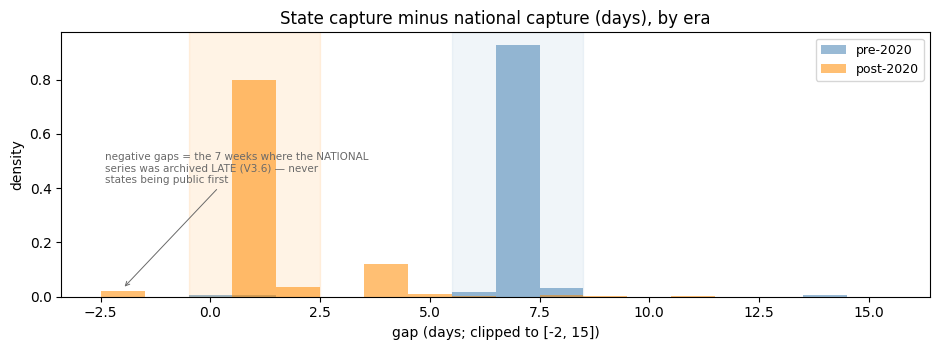

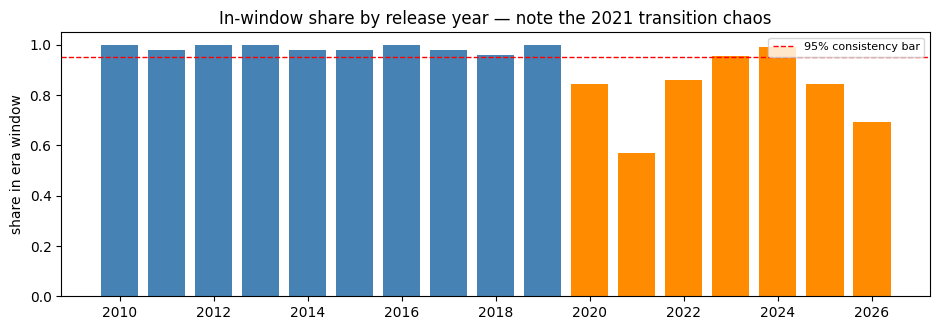

[PASS] V3.6   No state value available before its DOL report (leak check)  |  min state pub lag 13d across all 42k vintage rows  (criterion: min lag >= 12d (nothing can precede the report that first contains it))
       note: a NAIVE version of this check (state date < national ALFRED date) fires 357 false alarms on 7 weeks — those are weeks where the NATIONAL series was archived late (ALFRED artifact), not early state data — a negative gap never means the state number was PUBLIC first; see example below

'False leak' example: obs week 2025-09-20 — the NATIONAL series was captured 2025-11-20 (obs+61d vs the usual obs+12d = LATE), while states were on schedule:
   Alabama         2025-10-03 = obs + 13d (vs national: -48d)
   Alaska          2025-10-03 = obs + 13d (vs national: -48d)
   Arkansas        2025-10-03 = obs + 13d (vs national: -48d)


In [8]:
# V3.5 state vs national first-release alignment, per obs week
nat_rel = nat_v.set_index("obs_date")["first_release_date"]
al = cc_v[["state", "obs_date", "first_release_date", "pub_lag_days"]].copy()
al["nat_release"] = al["obs_date"].map(nat_rel)
al = al.dropna(subset=["nat_release"])
al["gap_days"] = (al["first_release_date"] - al["nat_release"]).dt.days

same_report = (al["gap_days"].between(0, 2)).mean()      # captured around the same (advance) report
next_report = (al["gap_days"].between(6, 8)).mean()      # captured around the following report (revised print)
add_check("V3", "V3.5", "State first release vs national release date, same obs week",
          "PASS" if same_report + next_report >= 0.90 else "WARN",
          metric=f"{same_report:.1%} within 0-2d of national release; {next_report:.1%} at +6-8d (next report)",
          threshold=">= 90% in one of the two report windows",
          note="IMPORTANT: this measures FRED/ALFRED CAPTURE order, not DOL publication order. "
               "DOL publishes state and national figures SIMULTANEOUSLY in the same Thursday report — "
               "states are not released later, they are ARCHIVED later by FRED. +6-8d cluster = "
               "pre-2020 (state series archived one report cycle later, storing the revised print); "
               "0-2d cluster = 2020+ (archived the day after the release, storing the advance print). "
               "For backtests, ALFRED capture dates are therefore a CONSERVATIVE availability assumption.")

# Worked examples — same obs week, state release vs national release, one week from each era
print("\nExamples (California / Texas / New York):")
for label, week in [("PRE-2020 era ", pd.Timestamp("2015-03-07")),
                    ("POST-2020 era", pd.Timestamp("2023-03-04"))]:
    sub = al[(al["obs_date"] == week) & al["state"].isin(["California", "Texas", "New York"])]
    if not len(sub):
        continue
    nr = sub["nat_release"].iloc[0]
    print(f"\n{label}: obs week ending {week.date()} | national release {nr.date()} ({nr.day_name()})")
    for _, r in sub.sort_values("state").iterrows():
        print(f"   {r['state']:<11s} first release {r['first_release_date'].date()} "
              f"({r['first_release_date'].day_name()})  gap = national {r['gap_days']:+.0f}d")

# V3.5b is the gap pattern CONSISTENT within each era?
# (uses the same rolling-median switch estimate that V3.7 derives)
lag_roll = (cc_v.sort_values("first_release_date")
                .set_index("first_release_date")["pub_lag_days"].rolling("56D").median())
switch_est = lag_roll[lag_roll < 16].index.min()
al["era"] = np.where(al["first_release_date"] >= switch_est, "post-2020", "pre-2020")
al["in_window"] = (((al["era"] == "pre-2020") & al["gap_days"].between(6, 8)) |
                   ((al["era"] == "post-2020") & al["gap_days"].between(0, 2)))
share_pre  = al.loc[al["era"] == "pre-2020", "in_window"].mean()
share_post = al.loc[al["era"] == "post-2020", "in_window"].mean()
post = al[al["era"] == "post-2020"]
mon_slip = post["gap_days"].between(3, 5).mean()   # Thursday release + 4d = Monday ingestion
add_check("V3", "V3.5b", "Era gap pattern consistency (is +7d / +1d stable within each era?)",
          "PASS" if share_pre >= 0.95 and share_post >= 0.95 else "WARN",
          metric=f"pre-2020: {share_pre:.1%} at +6-8d; post-2020: {share_post:.1%} at +0-2d "
                 f"(+{mon_slip:.1%} slip to +3-5d = Monday ingestion)",
          threshold=">= 95% in-window per era",
          note="pre-2020 is rock-solid (median gap +7d every year). post-2020 is modal +1d (Friday) "
               "but NOT fully consistent: ~10% of captures slip to Monday (+4d), and the 2021 "
               "transition year is chaotic (~57% in-window). Backtest staleness post-2020: "
               "13d typical, 16d conservative (Monday-slip tail). Negative gaps in the histogram are the "
               "7 late-NATIONAL-archive weeks (V3.6) — not states being published early.")
print("\nIn-window share and median gap by release year:")
yr_tab = al.groupby(al["first_release_date"].dt.year).agg(
    share_in_window=("in_window", "mean"), median_gap_d=("gap_days", "median"), rows=("gap_days", "size"))
print(yr_tab.round(3).to_string())

# ── visual 1: gap pattern by era ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9.5, 3.6))
bins = np.arange(-2.5, 16.5, 1)
for era, colr in [("pre-2020", "steelblue"), ("post-2020", "darkorange")]:
    ax.hist(al.loc[al["era"] == era, "gap_days"].clip(-2, 15), bins=bins,
            alpha=0.55, color=colr, label=era, density=True)
ax.axvspan(5.5, 8.5, color="steelblue", alpha=0.08)
ax.axvspan(-0.5, 2.5, color="darkorange", alpha=0.10)
ax.set(title="State capture minus national capture (days), by era",
       xlabel="gap (days; clipped to [-2, 15])", ylabel="density")
ax.annotate("negative gaps = the 7 weeks where the NATIONAL\nseries was archived LATE (V3.6) — never\nstates being public first",
            xy=(-2, 0.03), xytext=(-2.4, 0.42), fontsize=7.5, color="dimgray",
            arrowprops=dict(arrowstyle="->", lw=0.7, color="dimgray"))
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# ── visual 2: in-window share by release year ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9.5, 3.4))
yrs = yr_tab.index.astype(int)
ax.bar(yrs, yr_tab["share_in_window"],
       color=["steelblue" if y < switch_est.year else "darkorange" for y in yrs])
ax.axhline(0.95, color="red", ls="--", lw=1, label="95% consistency bar")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set(title="In-window share by release year — note the 2021 transition chaos",
       ylabel="share in era window", ylim=(0, 1.05))
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# V3.6 leak check — "could a backtest have seen state data before it was public?"
# The only public source is the Thursday DOL report: week X's continued claims first appear
# at X+12 days. A leaked timestamp would therefore show pub_lag_days < 12 — a value marked
# available BEFORE the number physically existed in any public document.
min_state_lag = int(cc_v["pub_lag_days"].min())
neg_vs_nat = al[al["gap_days"] < 0]
late_nat_weeks = neg_vs_nat["obs_date"].nunique()
add_check("V3", "V3.6", "No state value available before its DOL report (leak check)",
          "PASS" if min_state_lag >= 12 else "FAIL",
          metric=f"min state pub lag {min_state_lag}d across all 42k vintage rows",
          threshold="min lag >= 12d (nothing can precede the report that first contains it)",
          note=f"a NAIVE version of this check (state date < national ALFRED date) fires "
               f"{len(neg_vs_nat)} false alarms on {late_nat_weeks} weeks — those are weeks where the "
               f"NATIONAL series was archived late (ALFRED artifact), not early state data — a negative "
               f"gap never means the state number was PUBLIC first; see example below")

if len(neg_vs_nat):
    wk = neg_vs_nat.loc[neg_vs_nat["gap_days"].idxmin(), "obs_date"]
    nl = (nat_rel[wk] - wk).days
    print(f"\n'False leak' example: obs week {wk.date()} — the NATIONAL series was captured "
          f"{nat_rel[wk].date()} (obs+{nl}d vs the usual obs+12d = LATE), while states were on schedule:")
    for _, r in al[al["obs_date"] == wk].nsmallest(3, "first_release_date").iterrows():
        print(f"   {r['state']:<15s} {r['first_release_date'].date()} = obs + {r['pub_lag_days']:.0f}d "
              f"(vs national: {r['gap_days']:+.0f}d)")

### Understanding V3.7 — the capture-regime change

Timeline for any observation week ending Saturday **X**:

| When | What happens |
|---|---|
| Sat `X` | reference week ends |
| Thu `X+12` | this week's **advance** CC print is published — first public availability |
| Thu `X+19` | the *next* weekly report publishes the **revised** print for week X |

FRED's ingestion of *state* claims changed in **July 2020**:
- **Before:** states captured at `X+19` — the value stored in ALFRED is the **revised print** (grabbed the day it appeared, one full report cycle after the advance).
- **After:** states captured at `X+13` (the Friday after the Thursday report) — the stored value is the **advance print**, one day after publication.

Why it matters for backtesting: (1) *information timing* differs by ~a week between eras — use per-era availability lags; (2) the *content* differs too (advance vs revised print) — V4.3 bounds that gap (median −0.1%, tails to ±6%). The plot shows the weekly cross-state median capture lag stepping from 19 to 13 days at the switch; the red line is the 12-day public-availability floor.

[WARN] V3.7   Capture-lag regime stability  |  switch ~2020-07-10: median 19d -> 13d  (criterion: stable median lag across sample)
       note: pre-switch ALFRED stores the REVISED print (captured Sat+19d, i.e. on the following report day); post-switch the ADVANCE print (captured Sat+13d, the day after release). Backtests MUST use per-era lags; the print content differs by era too.


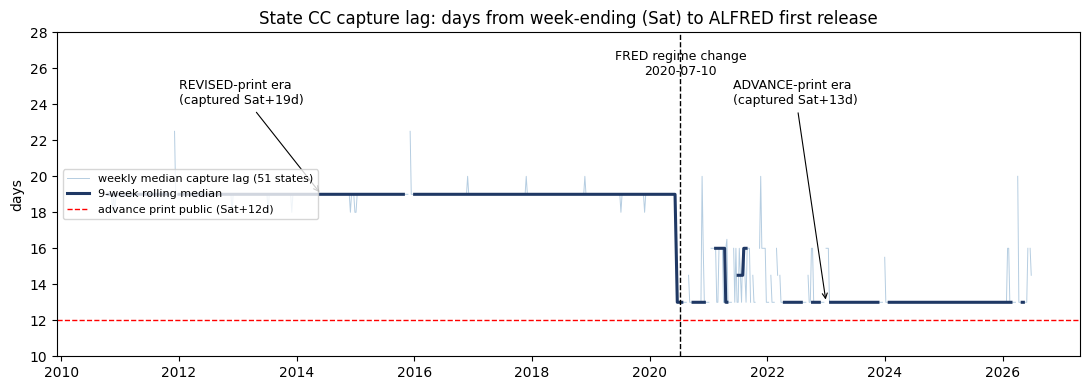

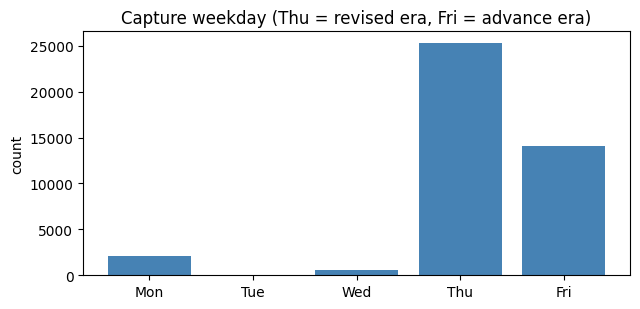

In [9]:
# V3.7 capture-lag regime stability over time (the 19d -> 13d shift)
cc_v["rel_year"] = cc_v["first_release_date"].dt.year

# locate the regime switch with a rolling median over release time
lag_ts = (cc_v.sort_values("first_release_date")
              .set_index("first_release_date")["pub_lag_days"]
              .rolling("56D").median())
switch_candidates = lag_ts[lag_ts < 16]
switch_date = switch_candidates.index.min() if len(switch_candidates) else None

era_old = cc_v[cc_v["first_release_date"] < switch_date] if switch_date is not None else cc_v.iloc[0:0]
era_new = cc_v[cc_v["first_release_date"] >= switch_date] if switch_date is not None else cc_v
regime_shift = switch_date is not None and abs(era_old["pub_lag_days"].median() - era_new["pub_lag_days"].median()) >= 3

add_check("V3", "V3.7", "Capture-lag regime stability",
          "WARN" if regime_shift else "PASS",
          metric=(f"switch ~{switch_date.date() if switch_date is not None else 'n/a'}: "
                  f"median {era_old['pub_lag_days'].median():.0f}d -> {era_new['pub_lag_days'].median():.0f}d"),
          threshold="stable median lag across sample",
          note="pre-switch ALFRED stores the REVISED print (captured Sat+19d, i.e. on the following "
               "report day); post-switch the ADVANCE print (captured Sat+13d, the day after release). "
               "Backtests MUST use per-era lags; the print content differs by era too.")

# ── visual 1: weekly cross-state median capture lag (the regime step) ─────────
lag_weekly = (cc_v.set_index("first_release_date")["pub_lag_days"]
              .sort_index().resample("W").median())

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(lag_weekly.index, lag_weekly.values, lw=0.7, color="steelblue", alpha=0.4,
        label="weekly median capture lag (51 states)")
ax.plot(lag_weekly.index, lag_weekly.rolling(9, center=True).median(), lw=2.2,
        color="#1f3864", label="9-week rolling median")
ax.axhline(12, color="red", ls="--", lw=1, label="advance print public (Sat+12d)")
if switch_date is not None:
    ax.axvline(switch_date, color="black", ls="--", lw=1)
    ax.annotate("REVISED-print era\n(captured Sat+19d)", xy=(pd.Timestamp("2014-06-01"), 19),
                xytext=(pd.Timestamp("2012-01-01"), 24),
                arrowprops=dict(arrowstyle="->", lw=0.8), fontsize=9)
    ax.annotate("ADVANCE-print era\n(captured Sat+13d)", xy=(pd.Timestamp("2023-01-01"), 13),
                xytext=(pd.Timestamp("2021-06-01"), 24),
                arrowprops=dict(arrowstyle="->", lw=0.8), fontsize=9)
    ax.annotate(f"FRED regime change\n{switch_date.date()}", xy=(switch_date, 27),
                fontsize=9, ha="center", va="top")
ax.set_ylim(10, 28)
ax.set(title="State CC capture lag: days from week-ending (Sat) to ALFRED first release", ylabel="days")
ax.legend(loc="center left", fontsize=8)
plt.tight_layout(); plt.show()

# ── visual 2: capture weekday ─────────────────────────────────────────────────
wd_all = cc_v["first_release_date"].dt.dayofweek.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.bar([wd_names[k] for k in wd_all.index], wd_all.values, color="steelblue")
ax.set(title="Capture weekday (Thu = revised era, Fri = advance era)", ylabel="count")
plt.tight_layout(); plt.show()

In [10]:
# V3.8 availability-frontier monotonicity (release order follows observation order)
inversions = 0
for state, g in cc_v.groupby("state"):
    rel = g.sort_values("obs_date")["first_release_date"].values
    inversions += int((rel[1:] < rel[:-1]).sum())
add_check("V3", "V3.8", "Release dates weakly increasing in obs order (per state)",
          "PASS" if inversions == 0 else "WARN",
          metric=f"{inversions} inversions", threshold="== 0",
          note="an inversion means a later week became visible before an earlier one — "
               "harmless if tiny, but the PIT builder must use the cummax frontier (it does)")

# V3.9 PIT look-ahead guard: latest obs used at each as-of must have been released by then
rel_lookup = cc_v.set_index(["state", "obs_date"])["first_release_date"]
pit_keys = pd.MultiIndex.from_arrays([pit["state"], pit["cclaims_latest_obs"]])
pit_rel = rel_lookup.reindex(pit_keys).values
violations = int((pd.to_datetime(pit_rel) > pit["as_of_date"]).sum())
unmatched = int(pd.isna(pit_rel).sum())
add_check("V3", "V3.9", "PIT panel look-ahead guard (cclaims_latest_obs released <= as_of_date)",
          "PASS" if violations == 0 and unmatched == 0 else "FAIL",
          metric=f"{violations} violations, {unmatched} unmatched keys of {len(pit):,} rows",
          threshold="== 0")

[PASS] V3.8   Release dates weakly increasing in obs order (per state)  |  0 inversions  (criterion: == 0)
       note: an inversion means a later week became visible before an earlier one — harmless if tiny, but the PIT builder must use the cummax frontier (it does)
[PASS] V3.9   PIT panel look-ahead guard (cclaims_latest_obs released <= as_of_date)  |  0 violations, 0 unmatched keys of 41,718 rows  (criterion: == 0)


## V4 — Revision behavior: first release and after

| Check | Question it answers |
|---|---|
| V4.1 | How often does a first print get revised at all (endpoint: first vs current)? |
| V4.1b | Where are the revisions concentrated (states / periods)? |
| V4.2 | Do values change mid-life and net out — invisible to the endpoint check? |
| V4.3 | How different is an *advance print* from its *revised print* — does the V3.7 era mixing matter? |

Three layers: (1) **first release vs current** across all states — spoiler: **not** negligible (~3% of obs), heavily concentrated in a few chronic-reviser states and 2020–22; (2) **full vintage trajectory** (`output_type=2`) for sample states incl. Hawaii, the worst chronic reviser; (3) **national calibration**: the national series archives *both* the advance and the revised print of every week, so we use it to measure how different the two prints typically are — which bounds the inconsistency introduced by the V3.7 capture-regime change.

*(The TX 2024-06 forensic case — a data error discovered by V4.1 — is presented as V5.4 with the other anomalies.)*

[WARN] V4.1   Endpoint revision rate (first release vs current)  |  1403 of 42,124 obs revised (3.33%)  (criterion: PASS < 0.5%, WARN < 5%)
       note: NOT the near-zero rate a small-sample probe suggests: revisions are real but concentrated — see the by-state and by-year breakdowns; full exception list feeds V9.4
[WARN] V4.1b  Revisions concentrated (chronic states + 2020-22 window)  |  top-4 states = 56% of exceptions: Hawaii n=404 (med |0.2%|), Pennsylvania n=168 (med |0.1%|), New Mexico n=111 (med |3.0%|), Maryland n=104 (med |0.1%|)  (criterion: documented)
       note: chronic revisers publish systematically preliminary first prints — consider state-specific noise handling or a revised_later flag feature; 2020-22 corrections are pandemic-era admin fixes

Exceptions by year:
obs_date
2010     27
2011      9
2012     18
2013     70
2014     37
2015     54
2016     28
2017     27
2018     60
2019     93
2020    298
2021    150
2022    162
2023    117
2024    121
2025     99
2026   

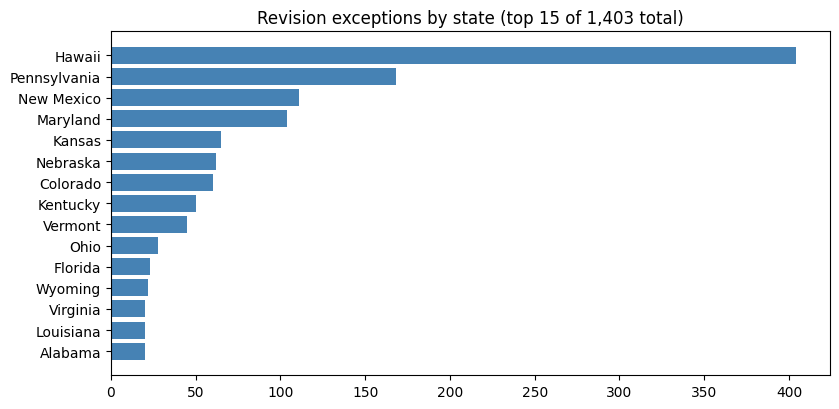

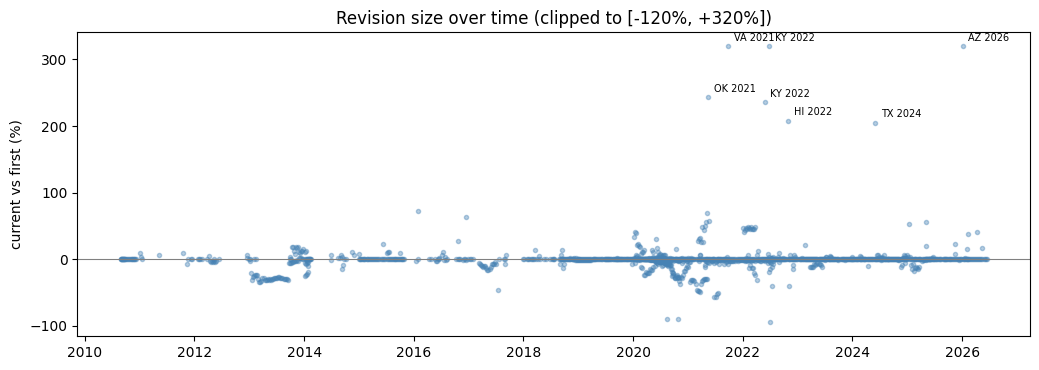

In [11]:
# V4.1 endpoint revisions: first release vs current, all states
rev = cc_v.merge(cc_c[["state", "obs_date", "value_current"]], on=["state", "obs_date"], how="inner")
rev["revision"] = rev["value_current"] - rev["value_first_release"]
rev["revision_pct"] = rev["revision"] / rev["value_first_release"] * 100
exceptions = rev[rev["revision"] != 0].copy()
share_revised = len(exceptions) / len(rev)
add_check("V4", "V4.1", "Endpoint revision rate (first release vs current)",
          "PASS" if share_revised < 0.005 else ("WARN" if share_revised < 0.05 else "FAIL"),
          metric=f"{len(exceptions)} of {len(rev):,} obs revised ({share_revised:.2%})",
          threshold="PASS < 0.5%, WARN < 5%",
          note="NOT the near-zero rate a small-sample probe suggests: revisions are real but concentrated "
               "— see the by-state and by-year breakdowns; full exception list feeds V9.4")

# concentration: chronic-reviser states and the pandemic-correction window
by_state = (exceptions.groupby("state")
            .agg(n=("obs_date", "count"), med_abs_pct=("revision_pct", lambda s: s.abs().median()))
            .sort_values("n", ascending=False))
top_share = by_state["n"].head(4).sum() / len(exceptions)
add_check("V4", "V4.1b", "Revisions concentrated (chronic states + 2020-22 window)",
          "WARN",
          metric=f"top-4 states = {top_share:.0%} of exceptions: "
                 + ", ".join(f"{s} n={int(r.n)} (med |{r.med_abs_pct:.1f}%|)" for s, r in by_state.head(4).iterrows()),
          threshold="documented",
          note="chronic revisers publish systematically preliminary first prints — consider state-specific "
               "noise handling or a revised_later flag feature; 2020-22 corrections are pandemic-era admin fixes")

print("\nExceptions by year:")
print(exceptions.groupby(exceptions["obs_date"].dt.year).size().to_string())
print("\nTop 30 largest exceptions by |%|:")
exc_view = exceptions[["state", "obs_date", "first_release_date",
                       "value_first_release", "value_current", "revision_pct"]].copy()
exc_view["obs_date"] = exc_view["obs_date"].dt.strftime("%Y-%m-%d")
exc_view["first_release_date"] = exc_view["first_release_date"].dt.strftime("%Y-%m-%d")
print(exc_view.sort_values("revision_pct", key=abs, ascending=False).head(30).to_string(index=False))
exceptions.to_csv("claims_revision_exceptions.csv", index=False)
print("\nFull exception list saved to claims_revision_exceptions.csv")

# ── visual 1: where are the revisions? ────────────────────────────────────────
top15 = by_state.head(15)
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.barh(list(top15.index)[::-1], list(top15["n"])[::-1], color="steelblue")
ax.set_title(f"Revision exceptions by state (top 15 of {len(exceptions):,} total)")
plt.tight_layout(); plt.show()

# ── visual 2: how big, and when? ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10.5, 3.8))
clipped = exceptions["revision_pct"].clip(-120, 320)
ax.scatter(exceptions["obs_date"], clipped, s=9, alpha=0.4, color="steelblue")
ax.axhline(0, color="gray", lw=0.8)
big = exceptions[exceptions["revision_pct"].abs() > 150]
for _, r in big.iterrows():
    ax.annotate(f"{r['abbr']} {r['obs_date'].year}", (r["obs_date"], min(r["revision_pct"], 320)),
                fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.set(title="Revision size over time (clipped to [-120%, +320%])", ylabel="current vs first (%)")
plt.tight_layout(); plt.show()

In [12]:
# V4.2 full vintage trajectories (output_type=2) — core sample + Hawaii (worst chronic reviser)
CORE   = {"CACCLAIMS": "California", "TXCCLAIMS": "Texas", "NYCCLAIMS": "New York",
          "FLCCLAIMS": "Florida", "MICCLAIMS": "Michigan"}
CHRONIC = {"HICCLAIMS": "Hawaii"}

traj_summary = {}
for sid, state in {**CORE, **CHRONIC}.items():
    d = fred_get({"series_id": sid, "realtime_start": "1776-07-04", "realtime_end": "9999-12-31",
                  "output_type": 2, "limit": 100000})
    t = pd.DataFrame(d["observations"])
    vcols = [c for c in t.columns if c.startswith(sid)]
    vals = t[vcols].replace(".", np.nan).astype(float)
    n_distinct = vals.apply(lambda r: r.dropna().nunique(), axis=1)
    traj_summary[state] = {"obs": len(t), "vintages": len(vcols),
                           "multi": int((n_distinct > 1).sum()),
                           "max_values": int(n_distinct.max())}
    time.sleep(0.5)

core_multi = sum(traj_summary[s]["multi"] for s in CORE.values())
core_obs   = sum(traj_summary[s]["obs"] for s in CORE.values())
add_check("V4", "V4.2", "Intermediate revisions bounded (full trajectory, 5 core states)",
          "PASS" if core_multi / core_obs < 0.005 else "WARN",
          metric=f"core states: {core_multi} multi-valued obs of {core_obs:,} ({core_multi/core_obs:.2%}); "
                 f"Hawaii: {traj_summary['Hawaii']['multi']} of {traj_summary['Hawaii']['obs']} "
                 f"(up to {traj_summary['Hawaii']['max_values']} values per obs)",
          threshold="core < 0.5% (chronic states reported separately)",
          note="core states are (near-)single-valued across all vintages, so V4.1's endpoint join "
               "captures their revision behavior; Hawaii revises repeatedly (up to 5 values per week) — "
               "its first prints are genuinely preliminary")
for state, s in traj_summary.items():
    print(f"  {state}: {s['obs']} obs x {s['vintages']} vintages; multi-valued: {s['multi']} (max {s['max_values']} values)")

[PASS] V4.2   Intermediate revisions bounded (full trajectory, 5 core states)  |  core states: 49 multi-valued obs of 10,556 (0.46%); Hawaii: 405 of 2152 (up to 5 values per obs)  (criterion: core < 0.5% (chronic states reported separately))
       note: core states are (near-)single-valued across all vintages, so V4.1's endpoint join captures their revision behavior; Hawaii revises repeatedly (up to 5 values per week) — its first prints are genuinely preliminary
  California: 2108 obs x 820 vintages; multi-valued: 5 (max 2 values)
  Texas: 2108 obs x 819 vintages; multi-valued: 4 (max 2 values)
  New York: 2107 obs x 822 vintages; multi-valued: 14 (max 2 values)
  Florida: 2107 obs x 822 vintages; multi-valued: 24 (max 3 values)
  Michigan: 2126 obs x 821 vintages; multi-valued: 2 (max 2 values)
  Hawaii: 2152 obs x 831 vintages; multi-valued: 405 (max 5 values)


[PASS] V4.3   Advance vs revised print: how different are they? (national calibration)  |  median -0.09%, IQR [-0.39%, +0.21%], max |6.4%|  (criterion: informational calibration)
       note: the typical advance->revised change is ~-0.1% (the advance slightly OVERSTATES claims), IQR +-0.3%, tails ~6% in COVID weeks. VERDICT: the V3.7 era mixing (revised prints pre-2020 vs advance prints post-2020) is a second-order inconsistency for state features — acceptable; add an era dummy if precise levels matter.


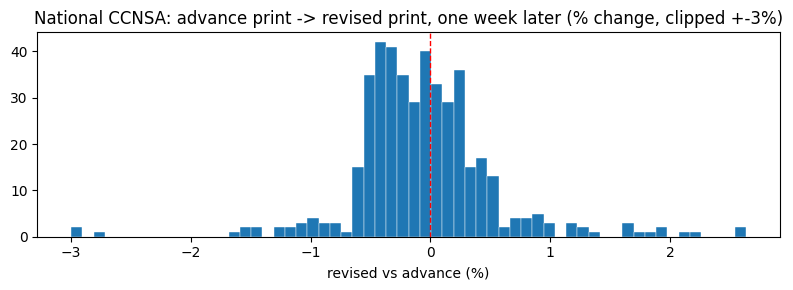

In [13]:
# V4.3 the advance -> revised gap, calibrated on the national series (CCNSA)
#
# WHY THIS CHECK EXISTS: V3.7 showed the state vintages MIX print types across eras —
# pre-2020 rows hold the REVISED print, post-2020 rows hold the ADVANCE print. If the two
# prints differed materially, our feature would be inconsistent across eras. We cannot
# measure the advance->revised step on states directly: ALFRED almost never stores both
# prints for a state week (pre-2020 the advance was never archived; post-2020 the revision
# rarely is). The NATIONAL series archives every step of every week -> use it to calibrate
# how big a typical advance->revised change is.
d = fred_get({"series_id": "CCNSA", "realtime_start": "2018-01-01", "realtime_end": "9999-12-31",
              "observation_start": "2018-01-01", "output_type": 2, "limit": 100000})
t = pd.DataFrame(d["observations"])
vcols = [c for c in t.columns if c.startswith("CCNSA")]
vals = t[vcols].replace(".", np.nan).astype(float)

def advance_and_rev1(row):
    v = row.dropna().values
    if len(v) == 0:
        return pd.Series({"advance": np.nan, "rev1": np.nan})
    uniq = v[np.insert(v[:-1] != v[1:], 0, True)]
    return pd.Series({"advance": uniq[0], "rev1": uniq[1] if len(uniq) > 1 else np.nan})

ar = vals.apply(advance_and_rev1, axis=1).dropna()
ar["rev_pct"] = (ar["rev1"] / ar["advance"] - 1) * 100
add_check("V4", "V4.3", "Advance vs revised print: how different are they? (national calibration)",
          "PASS",
          metric=f"median {ar['rev_pct'].median():+.2f}%, IQR [{ar['rev_pct'].quantile(.25):+.2f}%, "
                 f"{ar['rev_pct'].quantile(.75):+.2f}%], max |{ar['rev_pct'].abs().max():.1f}%|",
          threshold="informational calibration",
          note="the typical advance->revised change is ~-0.1% (the advance slightly OVERSTATES claims), "
               "IQR +-0.3%, tails ~6% in COVID weeks. VERDICT: the V3.7 era mixing (revised prints "
               "pre-2020 vs advance prints post-2020) is a second-order inconsistency for state "
               "features — acceptable; add an era dummy if precise levels matter.")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(ar["rev_pct"].clip(-3, 3), bins=60, edgecolor="white", linewidth=0.3)
ax.axvline(0, color="red", ls="--", lw=1)
ax.set(title="National CCNSA: advance print -> revised print, one week later (% change, clipped +-3%)",
       xlabel="revised vs advance (%)")
plt.tight_layout(); plt.show()

## V5 — Outliers, staleness & reporting artifacts

| Check | Question it answers |
|---|---|
| V5.1 | Are there frozen/stale stretches masquerading as data (repeat-value runs)? |
| V5.2 | Which extreme weekly moves are real events (COVID), calendar mechanics (holidays), or unexplained? |
| V5.3 | Do some states report rounded numbers (higher noise floor for WoW features)? |
| V5.4 | Case study — the TX 2024-06 first print: did the +100k error really happen, and which print was wrong? |

[WARN] V5.1   Stale-value runs (identical consecutive weeks, value >= 10k)  |  75 runs in current values; 34 in first-release values  (criterion: == 0 ideally)
       note: known: CA late-2020 processing pause (EDD backlog) froze FIRST-RELEASE prints — visible in the vintage data even where current data was later corrected; treat runs as stale/missing, not signal
First-release stale runs (PIT-relevant — a live model saw these):
         state      start  weeks     value
    California 2020-09-12      4 2802145.0
       Arizona 2025-08-23      2   31134.0
      Oklahoma 2015-08-22      2   21803.0
        Nevada 2025-12-27      2   29877.0
North Carolina 2023-11-04      2   19794.0
      Oklahoma 2011-11-05      2   23286.0
      Oklahoma 2012-04-07      2   22532.0
      Oklahoma 2014-09-13      2   15032.0
      Oklahoma 2014-10-18      2   14615.0
        Oregon 2012-07-21      2   48672.0

Current-value stale runs:
   state      start  weeks    value
 Alabama 1987-01-24      2  4742

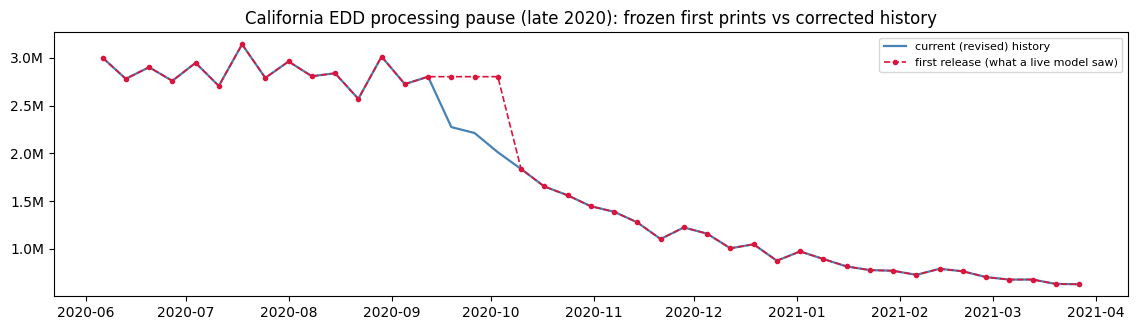

In [14]:
# V5.1 stale-value runs: consecutive identical weekly values (claims are 5-7 digit counts;
# exact repeats are near-impossible organically for large states).
# Checked on BOTH current values and first-release values: corrections can hide a stale run
# from current data (e.g. CA's late-2020 EDD pause repeats were later revised away).
def find_stale_runs(df, value_col):
    runs = []
    for state, g in df.groupby("state"):
        g = g.sort_values("obs_date")
        run_id = (g[value_col] != g[value_col].shift()).cumsum()
        for _, run in g.groupby(run_id):
            if len(run) >= 2 and run[value_col].iloc[0] >= 10_000:
                runs.append({"state": state, "start": run["obs_date"].min().date(),
                             "weeks": len(run), "value": run[value_col].iloc[0]})
    return pd.DataFrame(runs)

stale_cur   = find_stale_runs(cc_c, "value_current")
stale_first = find_stale_runs(cc_v, "value_first_release")
add_check("V5", "V5.1", "Stale-value runs (identical consecutive weeks, value >= 10k)",
          "WARN" if len(stale_cur) + len(stale_first) else "PASS",
          metric=f"{len(stale_cur)} runs in current values; {len(stale_first)} in first-release values",
          threshold="== 0 ideally",
          note="known: CA late-2020 processing pause (EDD backlog) froze FIRST-RELEASE prints — "
               "visible in the vintage data even where current data was later corrected; treat runs "
               "as stale/missing, not signal")
if len(stale_first):
    print("First-release stale runs (PIT-relevant — a live model saw these):")
    print(stale_first.sort_values("weeks", ascending=False).head(10).to_string(index=False))
if len(stale_cur):
    print("\nCurrent-value stale runs:")
    print(stale_cur.sort_values("weeks", ascending=False).head(10).to_string(index=False))

# ── visual: the flagship stale run — CA EDD pause, first prints vs corrected ──
ca_v = cc_v[(cc_v["state"] == "California") & cc_v["obs_date"].between("2020-06-01", "2021-03-31")]
ca_c2 = cc_c[(cc_c["state"] == "California") & cc_c["obs_date"].between("2020-06-01", "2021-03-31")]
fig, ax = plt.subplots(figsize=(11.5, 3.4))
ax.plot(ca_c2["obs_date"], ca_c2["value_current"], lw=1.6, color="steelblue", label="current (revised) history")
ax.plot(ca_v["obs_date"], ca_v["value_first_release"], lw=1.2, ls="--", marker=".", ms=6,
        color="crimson", label="first release (what a live model saw)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
ax.set_title("California EDD processing pause (late 2020): frozen first prints vs corrected history")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

[WARN] V5.2   Extreme weekly moves classified (|robust z| > 6 on dlog)  |  1475 extreme moves: 224 COVID, 731 holiday, 167 pre-1990 era, 353 unexplained modern  (criterion: unexplained modern < 0.2% of panel)
       note: COVID moves are genuine macro events — keep but regime-flag; pre-1990 spikes reflect the noisier startup era (see V1.4/V2.2a); the modern unexplained list needs eyeballing before use
               state   obs_date  value_current        rz
District of Columbia 1994-01-22        14877.0 27.183201
           Louisiana 2008-09-13        35542.0 26.280470
           Louisiana 2005-09-17       183162.0 26.181530
           Louisiana 2005-09-10        82524.0 24.934424
           Tennessee 1994-11-05        30953.0 24.533012
            Illinois 1990-02-10       146357.0 23.223376
             Georgia 2022-03-26        74171.0 21.408717
            Virginia 2021-12-04        38389.0 21.184397
             Georgia 2022-02-26        82217.0 21.182795
District of Columbia 2021

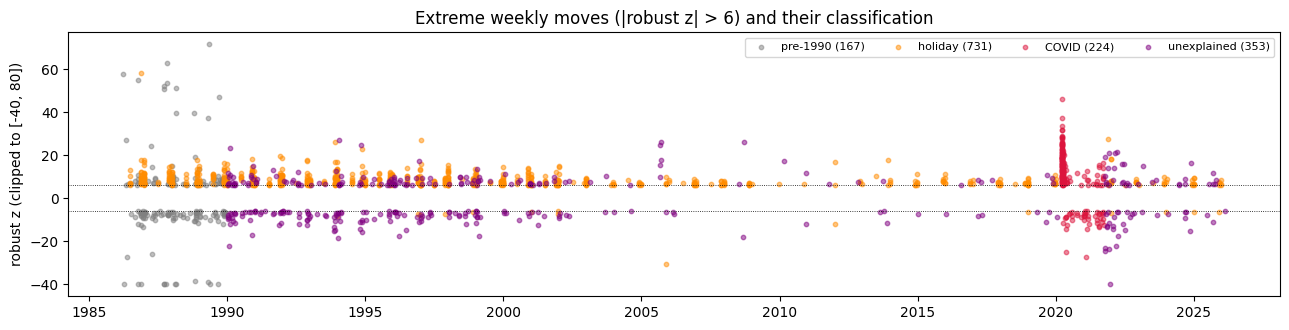

In [15]:
# V5.2 outlier scan on weekly log-changes, robust z (MAD), classified
def holiday_weeks(dates):
    """True if the Sat-ending week contains New Year, Jul 4, Thanksgiving or Christmas."""
    years = range(dates.dt.year.min() - 1, dates.dt.year.max() + 1)
    hols = []
    for y in years:
        hols += [pd.Timestamp(y, 1, 1), pd.Timestamp(y, 7, 4), pd.Timestamp(y, 12, 25)]
        nov = pd.date_range(f"{y}-11-01", f"{y}-11-30", freq="D")
        hols.append(nov[nov.dayofweek == 3][3])  # 4th Thursday
    hols = pd.DatetimeIndex(hols)
    return dates.apply(lambda d: ((hols > d - pd.Timedelta(days=7)) & (hols <= d)).any())

out_rows = []
for state, g in cc_c.groupby("state"):
    g = g.sort_values("obs_date").copy()
    v = g["value_current"].where(g["value_current"] > 0)   # V1.4 rule: zeros = missing (no log(0) infs)
    g["dlog"] = np.log(v).diff()
    d = g["dlog"].dropna()
    mad = (d - d.median()).abs().median() * 1.4826
    g["rz"] = (g["dlog"] - d.median()) / mad
    out_rows.append(g[g["rz"].abs() > 6])
outliers = pd.concat(out_rows)
outliers["covid"] = outliers["obs_date"].between("2020-03-01", "2021-09-30")
outliers["holiday"] = holiday_weeks(outliers["obs_date"])
outliers["early_era"] = outliers["obs_date"] < "1990-01-01"
unexplained = outliers[~outliers["covid"] & ~outliers["holiday"]]
unexpl_modern = unexplained[~unexplained["early_era"]]

add_check("V5", "V5.2", "Extreme weekly moves classified (|robust z| > 6 on dlog)",
          "PASS" if len(unexpl_modern) / len(cc_c) < 0.002 else "WARN",
          metric=f"{len(outliers)} extreme moves: {int(outliers['covid'].sum())} COVID, "
                 f"{int((outliers['holiday'] & ~outliers['covid']).sum())} holiday, "
                 f"{int(unexplained['early_era'].sum())} pre-1990 era, {len(unexpl_modern)} unexplained modern",
          threshold="unexplained modern < 0.2% of panel",
          note="COVID moves are genuine macro events — keep but regime-flag; pre-1990 spikes reflect the "
               "noisier startup era (see V1.4/V2.2a); the modern unexplained list needs eyeballing before use")
if len(unexpl_modern):
    print(unexpl_modern.nlargest(15, "rz", keep="all")[["state", "obs_date", "value_current", "rz"]]
          .to_string(index=False))

# ── visual: extreme moves over time, classified ───────────────────────────────
cat = np.where(outliers["covid"], "COVID",
      np.where(outliers["holiday"], "holiday",
      np.where(outliers["early_era"], "pre-1990", "unexplained")))
colors = {"pre-1990": "gray", "holiday": "darkorange", "COVID": "crimson", "unexplained": "purple"}
fig, ax = plt.subplots(figsize=(13, 3.4))
for c in ["pre-1990", "holiday", "COVID", "unexplained"]:
    m = cat == c
    ax.scatter(outliers.loc[m, "obs_date"], outliers.loc[m, "rz"].clip(-40, 80),
               s=10, alpha=0.5, color=colors[c], label=f"{c} ({int(m.sum())})")
ax.axhline(6, color="black", lw=0.6, ls=":"); ax.axhline(-6, color="black", lw=0.6, ls=":")
ax.set(title="Extreme weekly moves (|robust z| > 6) and their classification",
       ylabel="robust z (clipped to [-40, 80])")
ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

In [16]:
# V5.3 rounding/reporting artifacts: share of values divisible by 100
div100 = cc_c.groupby("state")["value_current"].apply(lambda s: (s % 100 == 0).mean())
flagged = div100[div100 > 0.05]  # ~1% expected by chance
add_check("V5", "V5.3", "Rounded-reporting states identified (share of values % 100 == 0)",
          "PASS" if len(flagged) == 0 else "WARN",
          metric=(f"{len(flagged)} states > 5%: " + ", ".join(f"{s} {v:.0%}" for s, v in flagged.items())
                  if len(flagged) else "none > 5%"),
          threshold="expected ~1% by chance",
          note="rounded reporting inflates the noise floor for those states — matters for WoW features")

[WARN] V5.3   Rounded-reporting states identified (share of values % 100 == 0)  |  1 states > 5%: Ohio 6%  (criterion: expected ~1% by chance)
       note: rounded reporting inflates the noise floor for those states — matters for WoW features


[WARN] V5.4   TX 2024-06-01 first-print error confirmed in-dataset (48,748 -> 148,748)  |  first=48,748, current=148,748, neighbors mean=148,270  (criterion: neighbor consistency)
       note: first release was the data error (dropped leading digit); current value is credible. A strict PIT feature on ~2024-06-14 used the erroneous print — add a data-error dummy or winsorize WoW changes in backtests.
  obs_date  value_current
2024-05-04       134981.0
2024-05-11       144508.0
2024-05-18       140928.0
2024-05-25       145782.0
2024-06-01       148748.0
2024-06-08       154170.0
2024-06-15       152278.0
2024-06-22       157834.0
2024-06-29       148081.0
2024-07-06       155865.0


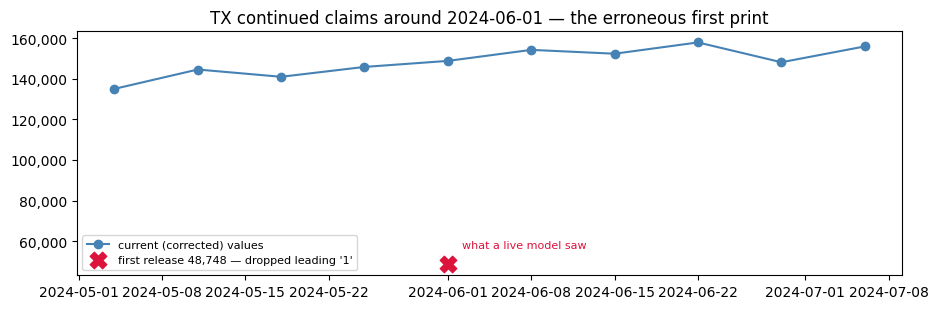

In [17]:
# V5.4 forensic case study (discovered by the V4.1 revision check): TX 2024-06-01
# Did this really happen in the dataset? Yes — the vintage table itself holds the first
# print 48,748 (captured 2024-06-14, verified against ALFRED output_type=4), while the
# current series holds 148,748. Exactly +100,000 => a dropped leading '1' in the first print.
tx = cc_c[(cc_c["state"] == "Texas") &
          (cc_c["obs_date"].between("2024-05-01", "2024-07-06"))][["obs_date", "value_current"]]
tx_exc = exceptions[(exceptions["state"] == "Texas") & (exceptions["obs_date"] == "2024-06-01")]
if len(tx_exc):
    fr, cur = tx_exc["value_first_release"].iloc[0], tx_exc["value_current"].iloc[0]
    neigh = tx[tx["obs_date"] != "2024-06-01"]["value_current"]
    fits_current = abs(cur - neigh.mean()) < 3 * neigh.std()
    fits_first   = abs(fr - neigh.mean()) < 3 * neigh.std()
    verdict = ("first release was the data error (dropped leading digit); current value is credible"
               if fits_current and not fits_first else "inconclusive — inspect manually")
    add_check("V5", "V5.4", "TX 2024-06-01 first-print error confirmed in-dataset (48,748 -> 148,748)",
              "WARN",  # WARN: a strict PIT backtest DID see the bad print on release day
              metric=f"first={fr:,.0f}, current={cur:,.0f}, neighbors mean={neigh.mean():,.0f}",
              threshold="neighbor consistency",
              note=f"{verdict}. A strict PIT feature on ~2024-06-14 used the erroneous print — "
                   "add a data-error dummy or winsorize WoW changes in backtests.")
    print(tx.to_string(index=False))

    fig, ax = plt.subplots(figsize=(9.5, 3.2))
    ax.plot(tx["obs_date"], tx["value_current"], marker="o", lw=1.5, color="steelblue",
            label="current (corrected) values")
    ax.scatter([pd.Timestamp("2024-06-01")], [fr], marker="X", s=140, color="crimson", zorder=5,
               label=f"first release {fr:,.0f} — dropped leading '1'")
    ax.annotate("what a live model saw", (pd.Timestamp("2024-06-01"), fr),
                xytext=(10, 12), textcoords="offset points", fontsize=8, color="crimson")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.set_title("TX continued claims around 2024-06-01 — the erroneous first print")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    add_check("V5", "V5.4", "TX 2024-06-01 first-print error", "WARN", metric="exception not found in data",
              threshold="n/a", note="re-check exception list — dataset may have been re-fetched after a FRED fix")

## V6 — Cross-sectional coherence

| Check | Question it answers |
|---|---|
| V6.1 | Do the 51 states add up to the national total (accounting for PR/VI)? |
| V6.2 | Does every state co-move with the national cycle — or is one decorrelated (data suspect)? |

[PASS] V6.1   Sum(51 states) reconciles with national CCNSA  |  median ratio 0.986, IQR width 0.007, range [0.957, 1.188]  (criterion: median in (0.90, 1.05), IQR < 0.05)
       note: gap = PR/VI + timing; large transient deviations flag data problems in specific weeks


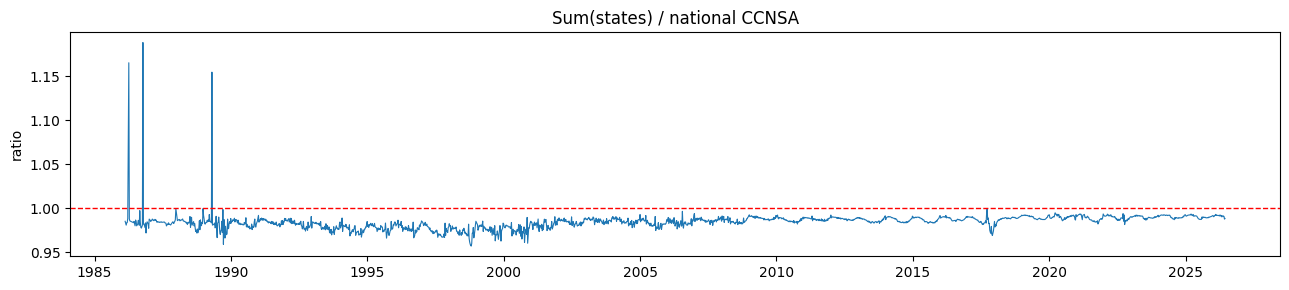

[PASS] V6.2   Cross-state co-movement (mean pairwise corr of YoY changes)  |  panel median 0.89; no state < 0.30  (criterion: every state's mean corr >= 0.30)
       note: a state decorrelated from the national cycle is a data-quality suspect, not an alpha source


/Users/danieloliveira/miniconda3/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


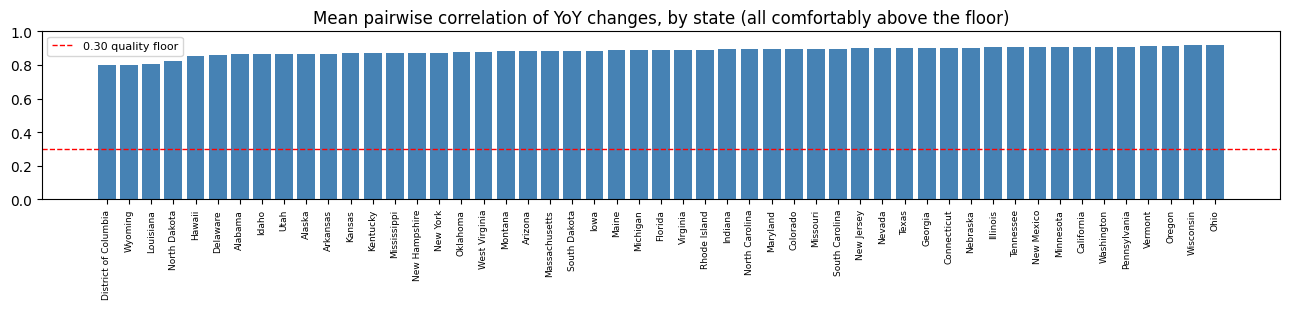

In [18]:
# V6.1 reconciliation: sum of 51 states vs national CCNSA
state_sum = cc_c.groupby("obs_date")["value_current"].agg(["sum", "count"])
full_weeks = state_sum[state_sum["count"] == 51]  # only weeks where all 51 report
recon = full_weeks.join(nat_cur.set_index("obs_date")["value"].rename("national"), how="inner")
recon["ratio"] = recon["sum"] / recon["national"]

med_ratio = recon["ratio"].median()
iqr_w = recon["ratio"].quantile(0.75) - recon["ratio"].quantile(0.25)
add_check("V6", "V6.1", "Sum(51 states) reconciles with national CCNSA",
          "PASS" if 0.90 < med_ratio < 1.05 and iqr_w < 0.05 else "WARN",
          metric=f"median ratio {med_ratio:.3f}, IQR width {iqr_w:.3f}, range "
                 f"[{recon['ratio'].min():.3f}, {recon['ratio'].max():.3f}]",
          threshold="median in (0.90, 1.05), IQR < 0.05",
          note="gap = PR/VI + timing; large transient deviations flag data problems in specific weeks")

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(recon.index, recon["ratio"], lw=0.8)
ax.axhline(1.0, color="red", ls="--", lw=1)
ax.set(title="Sum(states) / national CCNSA", ylabel="ratio")
plt.tight_layout(); plt.show()

# V6.2 cross-state co-movement (YoY log changes, business-cycle coherence)
wide = cc_c.pivot(index="obs_date", columns="state", values="value_current").sort_index()
yoy = np.log(wide).diff(52).dropna(how="all")
cmat = yoy.corr()
mean_corr = cmat.where(~np.eye(len(cmat), dtype=bool)).mean()
low_states = mean_corr[mean_corr < 0.30]
add_check("V6", "V6.2", "Cross-state co-movement (mean pairwise corr of YoY changes)",
          "PASS" if len(low_states) == 0 else "WARN",
          metric=f"panel median {mean_corr.median():.2f}; "
                 + (f"low: {dict(low_states.round(2))}" if len(low_states) else "no state < 0.30"),
          threshold="every state's mean corr >= 0.30",
          note="a state decorrelated from the national cycle is a data-quality suspect, not an alpha source")

# ── visual: co-movement by state ──────────────────────────────────────────────
mc = mean_corr.sort_values()
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.bar(range(len(mc)), mc.values, color="steelblue")
ax.set_xticks(range(len(mc))); ax.set_xticklabels(mc.index, rotation=90, fontsize=6.5)
ax.axhline(0.30, color="red", ls="--", lw=1, label="0.30 quality floor")
ax.set(title="Mean pairwise correlation of YoY changes, by state (all comfortably above the floor)",
       ylim=(0, 1))
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## V7 — Seasonality & stationarity (forecasting-critical)

State claims exist **only NSA**. The checks below quantify how much seasonal structure a model must handle and record the transform recommendation.

| Check | Question it answers |
|---|---|
| V7.1 | How strong is the annual seasonality a model must handle? |
| V7.2 | Are holiday weeks mechanically distorted — do we need calendar controls? |
| V7.3 | Which transform makes the series stationary (levels vs YoY log-diff)? |
| V7.4 | Is persistence plausible in every state (a broken-data tripwire)? |
| V7.5 | What did continued claims *exclude* during COVID (level-bias caveat)? |

[WARN] V7.1   Annual seasonality present and strong (ACF of dlog at lag 52, 2011-2019)  |  median 0.64, min 0.17, max 0.85  (criterion: documented — NSA data requires seasonal handling)
       note: use YoY transforms, 52-week differencing, or explicit week-of-year/holiday controls
[WARN] V7.2   Holiday-week effect quantified (mean dlog, holiday vs regular weeks)  |  holiday +0.100 vs regular -0.010 (spread +0.110 log-pts)  (criterion: spread <= 0.01 to ignore)
       note: if WARN: add holiday dummies or use 4-week MA features (pit already includes 4wma)


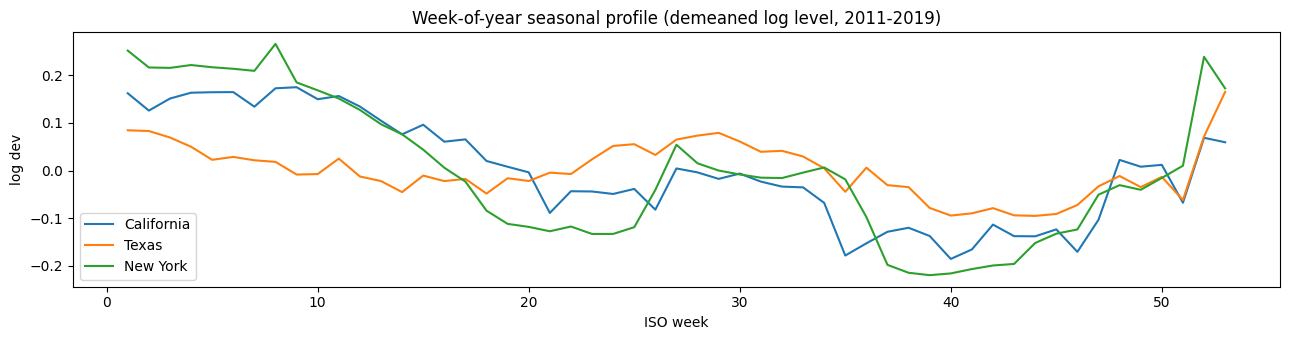

In [19]:
# V7.1 seasonality strength: autocorrelation of weekly log-changes at lag 52
# (computed on the pre-COVID window 2011-2019 to avoid regime contamination)
pre = wide.loc["2011":"2019"]
dlog_pre = np.log(pre).diff().dropna(how="all")
acf52 = dlog_pre.apply(lambda s: s.autocorr(52))
add_check("V7", "V7.1", "Annual seasonality present and strong (ACF of dlog at lag 52, 2011-2019)",
          "WARN",  # structural property to handle, not a defect
          metric=f"median {acf52.median():.2f}, min {acf52.min():.2f}, max {acf52.max():.2f}",
          threshold="documented — NSA data requires seasonal handling",
          note="use YoY transforms, 52-week differencing, or explicit week-of-year/holiday controls")

# V7.2 holiday-week mechanical effect
is_hol = holiday_weeks(pd.Series(dlog_pre.index))
hol_moves = dlog_pre[is_hol.values].stack()
reg_moves = dlog_pre[~is_hol.values].stack()
add_check("V7", "V7.2", "Holiday-week effect quantified (mean dlog, holiday vs regular weeks)",
          "WARN" if abs(hol_moves.mean() - reg_moves.mean()) > 0.01 else "PASS",
          metric=f"holiday {hol_moves.mean():+.3f} vs regular {reg_moves.mean():+.3f} "
                 f"(spread {hol_moves.mean()-reg_moves.mean():+.3f} log-pts)",
          threshold="spread <= 0.01 to ignore",
          note="if WARN: add holiday dummies or use 4-week MA features (pit already includes 4wma)")

# week-of-year profile for three large states
fig, ax = plt.subplots(figsize=(13, 3.5))
for st in ["California", "Texas", "New York"]:
    prof = np.log(pre[st]).groupby(pre.index.isocalendar().week.values).mean()
    ax.plot(prof.index, prof - prof.mean(), label=st)
ax.set(title="Week-of-year seasonal profile (demeaned log level, 2011-2019)",
       xlabel="ISO week", ylabel="log dev")
ax.legend(); plt.tight_layout(); plt.show()

[PASS] V7.3   Transform recommendation validated (ADF: log level vs YoY log-diff)  |  California: lvl p=0.00, yoy p=0.000; Texas: lvl p=0.00, yoy p=0.000; New York: lvl p=0.00, yoy p=0.000; Florida: lvl p=0.07, yoy p=0.000; Michigan: lvl p=0.00, yoy p=0.000  (criterion: YoY log-diff stationary (p < 0.05) for all sample states)
       note: work in YoY log-diff (or dlog with seasonal controls); levels are non-stationary
[PASS] V7.4   Persistence plausible in every state (AR1 of log level)  |  min 0.938 (New York), median 0.980  (criterion: AR1 >= 0.90 in all states)
       note: weekly insured-unemployment stocks are extremely persistent; a low-AR1 state = noisy/broken data
[WARN] V7.5   COVID program caveat documented  |  2020-2021 levels exclude PUA/PEUC  (criterion: documented)
       note: regular-state CC understates total insured unemployment during 2020-21; level-based cross-state comparisons in that window are biased — prefer changes or regime-flag it


/Users/danieloliveira/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/danieloliveira/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2908: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
/Users/danieloliveira/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2913: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())


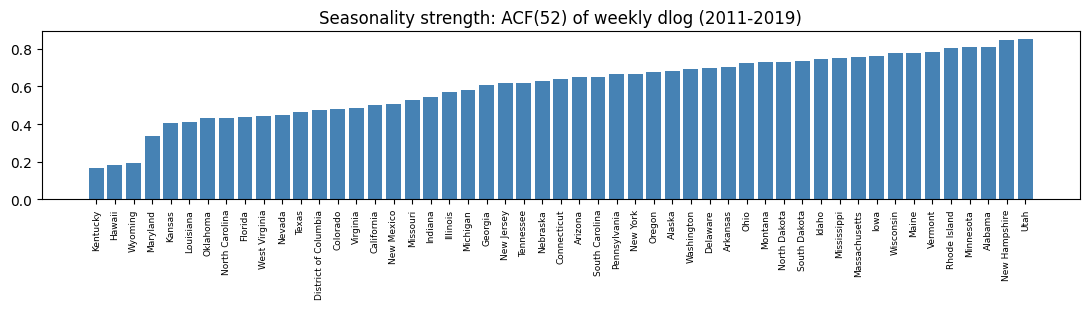

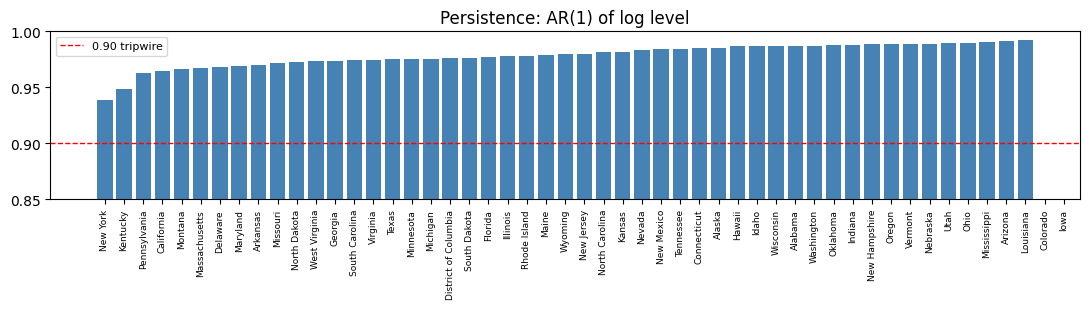

In [20]:
# V7.3 stationarity: ADF on log levels (expect non-stationary) vs YoY log-diff (expect stationary)
from statsmodels.tsa.stattools import adfuller
SAMPLE_STATES = ["California", "Texas", "New York", "Florida", "Michigan"]
adf_rows = []
for st in SAMPLE_STATES:
    s = np.log(wide[st].dropna())
    p_lvl = adfuller(s, autolag="AIC")[1]
    p_yoy = adfuller(s.diff(52).dropna(), autolag="AIC")[1]
    adf_rows.append({"state": st, "p_loglevel": p_lvl, "p_yoy": p_yoy})
adf_df = pd.DataFrame(adf_rows)
yoy_ok = (adf_df["p_yoy"] < 0.05).all()
add_check("V7", "V7.3", "Transform recommendation validated (ADF: log level vs YoY log-diff)",
          "PASS" if yoy_ok else "WARN",
          metric="; ".join(f"{r.state}: lvl p={r.p_loglevel:.2f}, yoy p={r.p_yoy:.3f}" for r in adf_df.itertuples()),
          threshold="YoY log-diff stationary (p < 0.05) for all sample states",
          note="work in YoY log-diff (or dlog with seasonal controls); levels are non-stationary")

# V7.4 persistence profile: lag-1 autocorr of weekly log levels — a data-quality tripwire
ar1 = wide.apply(lambda s: np.log(s.dropna()).autocorr(1))
weak = ar1[ar1 < 0.90]
add_check("V7", "V7.4", "Persistence plausible in every state (AR1 of log level)",
          "PASS" if len(weak) == 0 else "WARN",
          metric=f"min {ar1.min():.3f} ({ar1.idxmin()}), median {ar1.median():.3f}",
          threshold="AR1 >= 0.90 in all states",
          note="weekly insured-unemployment stocks are extremely persistent; a low-AR1 state = noisy/broken data")

add_check("V7", "V7.5", "COVID program caveat documented",
          "WARN", metric="2020-2021 levels exclude PUA/PEUC",
          threshold="documented",
          note="regular-state CC understates total insured unemployment during 2020-21; "
               "level-based cross-state comparisons in that window are biased — prefer changes or regime-flag it")

# ── visual 1: seasonality strength across all 51 states ───────────────────────
a52 = acf52.sort_values()
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.bar(range(len(a52)), a52.values, color="steelblue")
ax.set_xticks(range(len(a52))); ax.set_xticklabels(a52.index, rotation=90, fontsize=6.5)
ax.set_title("Seasonality strength: ACF(52) of weekly dlog (2011-2019)")
plt.tight_layout(); plt.show()

# ── visual 2: persistence across all 51 states ────────────────────────────────
a1 = ar1.sort_values()
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.bar(range(len(a1)), a1.values, color="steelblue")
ax.set_xticks(range(len(a1))); ax.set_xticklabels(a1.index, rotation=90, fontsize=6.5)
ax.axhline(0.90, color="red", ls="--", lw=1, label="0.90 tripwire")
ax.set_ylim(0.85, 1.0)
ax.set_title("Persistence: AR(1) of log level")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## V8 — Lead-lag readiness

| Check | Question it answers |
|---|---|
| V8.1 | Are the features indexed by information time (not observation time)? |
| V8.2 | Are signs and alignment wired correctly — do claims lead unemployment as they must? |
| V8.3 | How must weekly claims map onto monthly reference periods without leakage? |

Conventions that must hold before any lead-lag result is trusted:
- claims weeks end **Saturday**; the CC reference week trails the report by **12 days** (one week behind IC);
- the LAUS unemployment reference period is the week **containing the 12th** of the month — weekly-to-monthly aggregation must respect it;
- information time = **release date** (the PIT panel's Friday grid), never observation time.

[PASS] V8.1   PIT features indexed by information time (Friday grid, plausible staleness)  |  all Fridays: True; median cclaims staleness 20d  (criterion: Friday grid; staleness within release-calendar bounds)
[PASS] V8.2   Orientation: claims lead unemployment with positive sign (5 sample states)  |  California: peak corr 0.89 at k=0m; Texas: peak corr 0.88 at k=0m; New York: peak corr 0.90 at k=0m; Florida: peak corr 0.87 at k=0m; Michigan: peak corr 0.83 at k=0m  (criterion: >= 3/5 states peak at k >= 0 with corr > 0.3)
       note: validates sign/alignment wiring only — NOT the lead-lag analysis itself


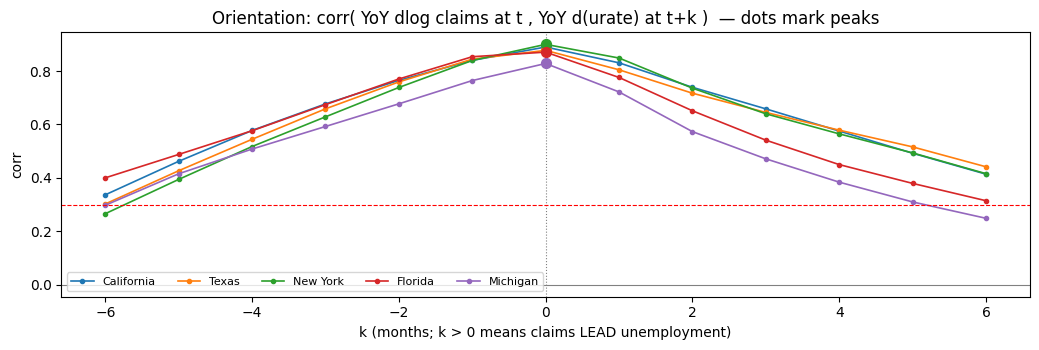

[WARN] V8.3   Weekly->monthly aggregation convention documented  |  LAUS reference week = week containing the 12th  (criterion: documented)
       note: when pairing claims with LAUS monthly data, align claims weeks to the reference week, not calendar-month averages (calendar averaging leaks post-reference-week info into the month)


In [21]:
# V8.1 PIT panel is release-date indexed (as-of Fridays, staleness matches the era lags from V3.7)
fridays = (pit["as_of_date"].dt.dayofweek == 4).all()
lag_med = pit["cclaims_lag_days"].median()
add_check("V8", "V8.1", "PIT features indexed by information time (Friday grid, plausible staleness)",
          "PASS" if fridays and 6 <= lag_med <= 26 else "FAIL",
          metric=f"all Fridays: {fridays}; median cclaims staleness {lag_med:.0f}d",
          threshold="Friday grid; staleness within release-calendar bounds")

# V8.2 orientation sanity: monthly claims should lead the unemployment rate with POSITIVE sign
# fetch monthly unemployment rates for the sample states directly (self-contained)
ABBR = {name: ab for name, ab, _ in STATES}
ur_rows = []
for st in SAMPLE_STATES:
    for o in fred_obs({"series_id": f"{ABBR[st]}UR", "observation_start": "1986-01-01", "frequency": "m"}):
        ur_rows.append({"state": st, "date": pd.to_datetime(o["date"]),
                        "unemployment_rate": float(o["value"])})
    time.sleep(0.3)
ur = pd.DataFrame(ur_rows)
ks = list(range(-6, 7))
results = []
for st in SAMPLE_STATES:
    m_claims = (cc_c[cc_c["state"] == st].set_index("obs_date")["value_current"]
                .resample("MS").mean())
    m_ur = ur[ur["state"] == st].set_index("date")["unemployment_rate"]
    dc = np.log(m_claims).diff(12).dropna()
    du = m_ur.diff(12).dropna()
    prof = [dc.corr(du.shift(-k)) for k in ks]   # k > 0: claims at t vs urate at t+k => claims LEAD
    best_i = int(np.nanargmax(prof))
    results.append({"state": st, "peak_lag_m": ks[best_i], "peak_corr": prof[best_i], "profile": prof})
res_df = pd.DataFrame([{k: v for k, v in r.items() if k != "profile"} for r in results])
n_ok = int(((res_df["peak_lag_m"] >= 0) & (res_df["peak_corr"] > 0.3)).sum())
add_check("V8", "V8.2", "Orientation: claims lead unemployment with positive sign (5 sample states)",
          "PASS" if n_ok >= 3 else "FAIL",
          metric="; ".join(f"{r.state}: peak corr {r.peak_corr:.2f} at k={r.peak_lag_m}m" for r in res_df.itertuples()),
          threshold=">= 3/5 states peak at k >= 0 with corr > 0.3",
          note="validates sign/alignment wiring only — NOT the lead-lag analysis itself")

# ── visual: the full cross-correlation profiles ───────────────────────────────
fig, ax = plt.subplots(figsize=(10.5, 3.6))
for r in results:
    line, = ax.plot(ks, r["profile"], marker=".", lw=1.2, label=r["state"])
    ax.scatter([r["peak_lag_m"]], [r["peak_corr"]], s=50, zorder=5, color=line.get_color())
ax.axvline(0, color="gray", lw=0.8, ls=":")
ax.axhline(0, color="gray", lw=0.8)
ax.axhline(0.3, color="red", lw=0.8, ls="--")
ax.set(title="Orientation: corr( YoY dlog claims at t , YoY d(urate) at t+k )  — dots mark peaks",
       xlabel="k (months; k > 0 means claims LEAD unemployment)", ylabel="corr")
ax.legend(fontsize=8, ncol=5)
plt.tight_layout(); plt.show()

add_check("V8", "V8.3", "Weekly->monthly aggregation convention documented",
          "WARN", metric="LAUS reference week = week containing the 12th",
          threshold="documented",
          note="when pairing claims with LAUS monthly data, align claims weeks to the reference week, "
               "not calendar-month averages (calendar averaging leaks post-reference-week info into the month)")

## V9 — Backtest readiness

| Check | Question it answers |
|---|---|
| V9.1 | From which date is the PIT panel complete enough to backtest on? |
| V9.2 | Is the universe stable — no state entering or exiting the panel? |
| V9.3 | What information staleness must a backtest assume, per era? |
| V9.4 | How many feature rows carry values that were later corrected (contamination bound)? |

[PASS] V9.1   PIT coverage complete after ramp-in  |  51/51 from 2010-11-05; 0 holes after that  (criterion: 0 holes)
       note: usable backtest window starts 2010-11-05


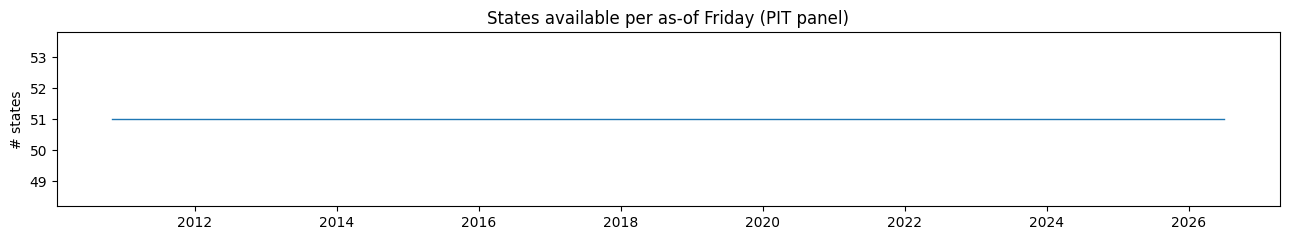

[WARN] V9.2   Universe stability (balanced panel over common window)  |  weeks per state: 2100-2107  (criterion: identical for all states)
       note: 1-7 week differences = the interior gaps enumerated in V2.2 (pre-1990 + VA 2026)
[WARN] V9.3   Era-specific information lag documented for backtests  |  {'post-switch': {'median': 13.0, 'min': 13, 'max': 27}, 'pre-switch': {'median': 20.0, 'min': 13, 'max': 27}}  (criterion: documented)
       note: apply per-era staleness — a constant-lag assumption misprices the pre-2020 era by ~1 week
[WARN] V9.4   PIT rows carrying later-revised first prints (two tiers)  |  t0 revised-later: 1388 rows (3.3%); any of t0..t7: 2825 rows (6.8%)  (criterion: t0 tier < 2% of rows)
       note: strict PIT correctly keeps these (that is what was known at the time) — but they are error-prone inputs concentrated in chronic-reviser states and 2020-22; RECOMMENDATION: add a revised_later flag column to the feature panel and winsorize WoW features


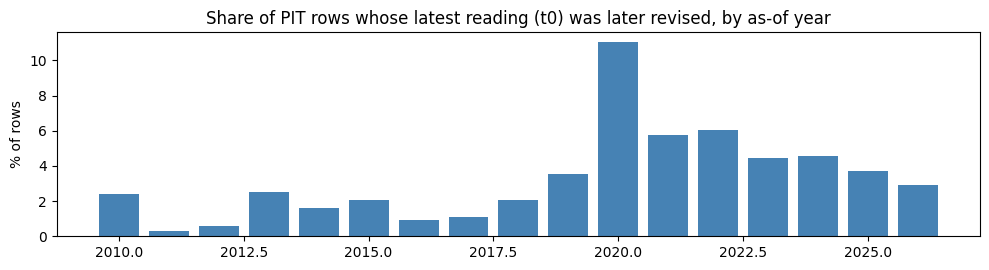

In [22]:
# V9.1 PIT coverage: 51/51 states at every as-of date after ramp-in
cov = pit.groupby("as_of_date")["state"].nunique()
full_start = cov[cov == 51].index.min()
holes = cov[(cov.index > full_start) & (cov < 51)]
add_check("V9", "V9.1", "PIT coverage complete after ramp-in",
          "PASS" if len(holes) == 0 else "FAIL",
          metric=f"51/51 from {full_start.date()}; {len(holes)} holes after that",
          threshold="0 holes",
          note=f"usable backtest window starts {full_start.date()}")

fig, ax = plt.subplots(figsize=(13, 2.5))
ax.plot(cov.index, cov.values, lw=1)
ax.set(title="States available per as-of Friday (PIT panel)", ylabel="# states")
plt.tight_layout(); plt.show()

# V9.2 universe stability (no entry/exit in the weekly panel)
weeks_per_state = cc_c[cc_c["obs_date"] >= starts.max()].groupby("state")["obs_date"].nunique()
add_check("V9", "V9.2", "Universe stability (balanced panel over common window)",
          "PASS" if weeks_per_state.nunique() == 1 else "WARN",
          metric=f"weeks per state: {weeks_per_state.min()}-{weeks_per_state.max()}",
          threshold="identical for all states",
          note="1-7 week differences = the interior gaps enumerated in V2.2 (pre-1990 + VA 2026)")

# V9.3 effective information lag by era (the number a backtest must assume)
pit_era = np.where(pit["as_of_date"] < (switch_date if switch_date is not None else pit["as_of_date"].min()),
                   "pre-switch", "post-switch")
lag_prof = pit.groupby(pit_era)["cclaims_lag_days"].agg(["median", "min", "max"])
add_check("V9", "V9.3", "Era-specific information lag documented for backtests",
          "WARN", metric=lag_prof.to_dict("index"), threshold="documented",
          note="apply per-era staleness — a constant-lag assumption misprices the pre-2020 era by ~1 week")

# V9.4 feature contamination from later-revised first prints (exceptions from V4.1)
# Two tiers: rows whose LATEST reading (t0) was later revised (most impactful — drives WoW features),
# and rows with ANY later-revised value inside the 8-week t0..t7 window.
exc_keys = set(zip(exceptions["state"], exceptions["obs_date"]))
t0_hit = pit.apply(lambda r: (r["state"], r["cclaims_latest_obs"]) in exc_keys, axis=1)

exc_by_state = {}
for s, d in exc_keys:
    exc_by_state.setdefault(s, []).append(d)
def window_hit(r):
    ds = exc_by_state.get(r["state"])
    if not ds:
        return False
    lo = r["cclaims_latest_obs"] - pd.Timedelta(weeks=7)
    return any(lo <= d <= r["cclaims_latest_obs"] for d in ds)
any_hit = pit.apply(window_hit, axis=1)

add_check("V9", "V9.4", "PIT rows carrying later-revised first prints (two tiers)",
          "PASS" if t0_hit.mean() < 0.02 else "WARN",
          metric=f"t0 revised-later: {int(t0_hit.sum())} rows ({t0_hit.mean():.1%}); "
                 f"any of t0..t7: {int(any_hit.sum())} rows ({any_hit.mean():.1%})",
          threshold="t0 tier < 2% of rows",
          note="strict PIT correctly keeps these (that is what was known at the time) — but they are "
               "error-prone inputs concentrated in chronic-reviser states and 2020-22; RECOMMENDATION: "
               "add a revised_later flag column to the feature panel and winsorize WoW features")

# ── visual: when do contaminated feature rows cluster? ────────────────────────
hit_by_year = pd.Series(t0_hit.values, index=pit["as_of_date"].dt.year).groupby(level=0).mean() * 100
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.bar(hit_by_year.index.astype(int), hit_by_year.values, color="steelblue")
ax.set(title="Share of PIT rows whose latest reading (t0) was later revised, by as-of year",
       ylabel="% of rows")
plt.tight_layout(); plt.show()

## V10 — Reproducibility & governance

| Check | Question it answers |
|---|---|
| V10.1 | Can this dataset be reproduced and audited byte-for-byte (hashes, pinned params)? |

In [23]:
def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

manifest = {
    "validated_at": pd.Timestamp.now().isoformat(),
    "source": "FRED/ALFRED api.stlouisfed.org — series {ABBR}CCLAIMS, {ABBR}ICLAIMS, CCNSA",
    "vintage_params": {"realtime_start": "1776-07-04", "realtime_end": "9999-12-31", "output_type": 4},
    "files": {f: {"sha256": sha256(f), "rows": int(pd.read_csv(f).shape[0])} for f in DATA_FILES.values()},
    "data_ranges": {
        "current_history": [str(df_c["obs_date"].min().date()), str(df_c["obs_date"].max().date())],
        "vintage_window":  [str(df_v["first_release_date"].min().date()), str(df_v["first_release_date"].max().date())],
        "pit_panel":       [str(pit["as_of_date"].min().date()), str(pit["as_of_date"].max().date())],
    },
}
with open("claims_validation_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)
add_check("V10", "V10.1", "Manifest written (hashes, params, ranges)",
          "PASS", metric="claims_validation_manifest.json", threshold="file exists",
          note="ALFRED queries with pinned realtime_* params are reproducible; re-fetch and diff hashes to audit")

[PASS] V10.1  Manifest written (hashes, params, ranges)  |  claims_validation_manifest.json  (criterion: file exists)
       note: ALFRED queries with pinned realtime_* params are reproducible; re-fetch and diff hashes to audit


## Validation report

In [24]:
QUESTIONS = {
    "V1.1":  "Do we have all 51 states in every table?",
    "V1.2":  "Is (state, claim_type, week) a unique key?",
    "V1.3":  "Are key fields complete (no nulls)?",
    "V1.4":  "Is every value parseable, finite and positive?",
    "V1.4b": "Are zeros ramp-in artifacts (leading) or mid-sample dropouts (interior)?",
    "V1.5":  "Did any state's fetch silently truncate?",
    "V2.1":  "Do obs dates follow the DOL Saturday week-ending convention?",
    "V2.2a": "Are there missing weeks in the pre-1990 history?",
    "V2.2b": "Are there missing weeks in modern data (live issues)?",
    "V2.3":  "Do all states cover the same window?",
    "V3.1":  "How far back can point-in-time be reconstructed?",
    "V3.2":  "Does the vintage calendar match the DOL mid-week release schedule?",
    "V3.3":  "Is the national first release the advance print at obs+12d?",
    "V3.4":  "On which weekday does FRED capture state data?",
    "V3.5":  "How long after the public release do state values appear?",
    "V3.5b": "Is the state-vs-national gap pattern stable within each era?",
    "V3.6":  "Could a backtest have seen state data before it was public?",
    "V3.7":  "Has FRED's capture timing / stored print type been stable?",
    "V3.8":  "Do weeks become available in order?",
    "V3.9":  "Does the PIT panel contain any look-ahead?",
    "V4.1":  "How often does a first print get revised at all?",
    "V4.1b": "Where are revisions concentrated?",
    "V4.2":  "Do values change mid-life and net out (invisible to endpoint checks)?",
    "V4.3":  "How big is the national advance-to-revised gap?",
    "V5.4":  "Did the TX 2024-06 +100k first-print error really happen, and which print was wrong?",
    "V5.1":  "Are there frozen/stale stretches masquerading as data?",
    "V5.2":  "Which extreme moves are real events vs calendar mechanics vs unexplained?",
    "V5.3":  "Do some states report rounded numbers (noise floor)?",
    "V6.1":  "Do the 51 states add up to the national total?",
    "V6.2":  "Does every state co-move with the national cycle?",
    "V7.1":  "How strong is the annual seasonality to handle?",
    "V7.2":  "Are holiday weeks mechanically distorted?",
    "V7.3":  "Which transform makes the series stationary?",
    "V7.4":  "Is persistence plausible in every state?",
    "V7.5":  "What did continued claims exclude during COVID?",
    "V8.1":  "Are features indexed by information time?",
    "V8.2":  "Do claims lead unemployment with the right sign (wiring check)?",
    "V8.3":  "How must weekly claims map onto monthly reference periods?",
    "V9.1":  "From which date is the PIT panel backtest-complete?",
    "V9.2":  "Is the universe stable (no entry/exit)?",
    "V9.3":  "What staleness must a backtest assume, per era?",
    "V9.4":  "How many feature rows carry later-corrected values?",
    "V10.1": "Can the dataset be reproduced and audited byte-for-byte?",
}

report = pd.DataFrame(checks)[["module", "id", "check", "result", "metric", "threshold", "note"]]
report.insert(3, "question", report["id"].map(QUESTIONS).fillna(""))
report.to_csv("claims_validation_report.csv", index=False)

counts = report["result"].value_counts()
print(f"Checks: {len(report)}  |  PASS {counts.get('PASS',0)}  WARN {counts.get('WARN',0)}  FAIL {counts.get('FAIL',0)}\n")

missing_q = report.loc[report["question"] == "", "id"].tolist()
if missing_q:
    print(f"NOTE: checks without a mapped question: {missing_q}")

def color(v):
    return {"PASS": "background-color:#d4edda", "WARN": "background-color:#fff3cd",
            "FAIL": "background-color:#f8d7da"}.get(v, "")
report.style.map(color, subset=["result"]).hide(axis="index")

Checks: 43  |  PASS 24  WARN 19  FAIL 0



module,id,check,question,result,metric,threshold,note
V1,V1.1,51 states present in all tables,Do we have all 51 states in every table?,PASS,"{'vintage': 51, 'current': 51, 'pit': 51}",== 51 everywhere,
V1,V1.2,"No duplicate (state, claim_type, obs_date) keys","Is (state, claim_type, week) a unique key?",PASS,"vintage=0, current=0, pit=0",== 0,
V1,V1.3,No nulls in key fields,Are key fields complete (no nulls)?,PASS,0 nulls,== 0,
V1,V1.4,"Values strictly positive, finite (parse consistency incl. int->float drift)","Is every value parseable, finite and positive?",WARN,"vintage bad=0; current zeros=15 (latest 1986-07-19), post-1990=0",0 bad; startup-era zeros tolerated as WARN,all zeros sit in Jan-Jul 1986 — RULE: treat values <= 0 as missing before any log transform. FRED int->float format drift coerced cleanly. Position analysis in V1.4b.
V1,V1.4b,Zero position: leading (ramp-in) vs interior (mid-sample dropout),Are zeros ramp-in artifacts (leading) or mid-sample dropouts (interior)?,WARN,"9 leading, 6 interior; interior post-1990: 0",interior == 0 ideally; pre-1990 interior tolerated as WARN,"leading zeros = series ramp-in, drop silently; INTERIOR zeros are dropouts inside live data (e.g. NJ iclaims Jul-1986: 13,777 -> 0 -> 0 -> 7,846) — must be masked BEFORE differencing or the surrounding WoW changes are corrupted too"
V1,V1.5,Row counts comparable across states (current history),Did any state's fetch silently truncate?,PASS,"min=2100, max=2112",max-min <= 15 weeks,small raggedness at series start (states begin reporting a few weeks apart in 1986)
V2,V2.1,All obs_date are Saturdays (DOL week-ending),Do obs dates follow the DOL Saturday week-ending convention?,PASS,0 non-Saturday,== 0,
V2,V2.2a,"Interior weekly gaps, pre-1990 startup era",Are there missing weeks in the pre-1990 history?,WARN,48 missing weeks across 22 states (1986-88),0 ideally; tolerated as WARN pre-1990,early DOL collection holes — RULE: forecasting pipelines must handle NaN weeks; do not forward-fill through gaps when computing WoW changes
V2,V2.2b,"Interior weekly gaps, post-1990 (live data issues)",Are there missing weeks in modern data (live issues)?,PASS,none,== 0; any occurrence must be investigated,a recent missing week = state failed to report / FRED shows '.' — monitor for backfill; PIT features skip the week automatically (availability frontier)
V2,V2.3,Panel edges aligned across states,Do all states cover the same window?,PASS,"start spread=5w, end spread=1w","start<=10w, end<=1w",common balanced window: 1986-02-08 -> 2026-06-13


## Gating decisions (go/no-go)

In [25]:
n_fail = int((report["result"] == "FAIL").sum())

print("=" * 78)
print(f"GATE STATUS: {'BLOCKED — resolve FAILs first' if n_fail else 'CLEARED with documented caveats'}")
print("=" * 78)
print(f"""
G1 — SCOPE CLEARED
  * Backtesting / PIT work:  {full_start.date()} onward (51/51 PIT coverage; strict ALFRED vintages)
  * Seasonality / climatology estimation: full 1986+ current history — with the V1.4/V2.2 rules
    (zeros -> missing, no forward-fill through gaps, pre-1990 treated as noisier startup era)
  * NOT cleared: treating pre-{vint_start.date()} data as point-in-time

G2 — REQUIRED TRANSFORMS (from V5/V7)
  * Work in YoY log-diffs (stationary) or dlog with week-of-year + holiday controls
  * Use 4-week MA features to suppress holiday/reporting noise (already in the PIT panel)
  * Regime-flag 2020-2021 (PUA/PEUC exclusion distorts levels; CA stale first prints)
  * Winsorize WoW features (isolated first-print data errors, e.g. TX 2024-06 dropped digit)

G3 — ALIGNMENT RULES FOR BACKTESTS (from V3/V4/V9)
  * Index all information by release date (Friday as-of grid), never by observation week
  * Apply PER-ERA staleness: pre-{switch_date.date() if switch_date is not None else 'n/a'} the vintage
    value is the REVISED print at Sat+19d; after, the ADVANCE print at Sat+13d
  * Revisions are NOT negligible panel-wide: {len(exceptions)} weeks ({len(exceptions)/len(rev):.1%}) were
    later corrected, concentrated in {', '.join(by_state.head(4).index)} and 2020-22 —
    carry a revised_later flag feature (list: claims_revision_exceptions.csv)
  * National advance->revised gap (median ~-0.2%, tails to ~5%) bounds the print-type mixing bias
""")

GATE STATUS: CLEARED with documented caveats

G1 — SCOPE CLEARED
  * Backtesting / PIT work:  2010-11-05 onward (51/51 PIT coverage; strict ALFRED vintages)
  * Seasonality / climatology estimation: full 1986+ current history — with the V1.4/V2.2 rules
    (zeros -> missing, no forward-fill through gaps, pre-1990 treated as noisier startup era)
  * NOT cleared: treating pre-2010-09-16 data as point-in-time

G2 — REQUIRED TRANSFORMS (from V5/V7)
  * Work in YoY log-diffs (stationary) or dlog with week-of-year + holiday controls
  * Use 4-week MA features to suppress holiday/reporting noise (already in the PIT panel)
  * Regime-flag 2020-2021 (PUA/PEUC exclusion distorts levels; CA stale first prints)
  * Winsorize WoW features (isolated first-print data errors, e.g. TX 2024-06 dropped digit)

G3 — ALIGNMENT RULES FOR BACKTESTS (from V3/V4/V9)
  * Index all information by release date (Friday as-of grid), never by observation week
  * Apply PER-ERA staleness: pre-2020-07-10 the vintage
 